<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DES VENTES SUR LE SITE WEB DE LA LIBRAIRIE LAPAGE</h1>
</div>

Brief de l’analyse <BR><BR><BR>
Nous souhaitons élaborer différents graphiques autour du chiffre d'affaires comme par exemples l’évolution dans le temps du :<BR><BR>
● chiffre d’affaires avec la moyenne mobile (tu pourras choisir la période : jour, semaine, mois, etc.),<BR>
● chiffre d’affaires par catégorie,<BR>
● nombre de clients par mois,<BR>
● nombre de transactions,<BR>
● nombre de produits vendus,<BR>
● etc.<BR><BR><BR>
Il serait également intéressant de faire un zoom sur les références :<BR><BR>
● les tops,<BR>
● les flops,<BR>
● la répartition par catégorie,<BR>
● etc.<BR>
Enfin, j’aimerais avoir quelques informations sur les profils de nos clients :<BR>
● répartition du chiffre d'affaires pour les clients BtoB,<BR>
● courbe de Lorenz,<BR>
● etc.<BR><BR><BR>
Après, toutes les informations et tous graphiques qui apporteraient de l’information pertinente sont les bienvenus !<BR>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [147]:
#Importation des librairies

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import pearsonr, spearmanr, fisher_exact, chi2_contingency, ttest_ind, f_oneway, norm, shapiro, levene
import pingouin as pg

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [2]:
#Importation des fichiers
df_customers = pd.read_csv("customers.csv")
df_products = pd.read_csv("products.csv")
df_transactions = pd.read_csv("transactions.csv")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier customers</h3>
</div>

In [3]:
#Consulter les dimensions et le contenu du fichier
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


3 attributs : id, sexe et année de naissance et aucune valeur nulle.

In [4]:
# On va voir à quoi ressemblent nos données. 
df_customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


On va vérifier chaque variable.

In [5]:
# vérification de la colonne client_id 
df_customers['client_id'].describe()

count       8623
unique      8623
top       c_4410
freq           1
Name: client_id, dtype: object

8623 valeurs unique, c'est bien notre clé primaire. Il faut quand même vérifier qu'ils sont tous au même format.

In [6]:
# je veux maintenant vérifier qu'ils sont otus au même format : "c_unesuitedechiffre"
mask_invalid_client_id = ~df_customers['client_id'].str.contains(r'^[a-zA-Z]_\d?', na=False)
invalid_rows = df_customers[mask_invalid_client_id]
invalid_rows

,client_id,sex,birth
2735,ct_0,f,2001
8494,ct_1,m,2001


j'ai deux clients qui ont "ct", j'ignore à quoi cela correspond. Je les laisse pour l'instant.

In [7]:
# On va regarder la variable sex
df_customers['sex'].describe()

count     8623
unique       2
top          f
freq      4491
Name: sex, dtype: object

In [8]:
# je veux vérifier les deux valeurs possibles pour être sûr que c'est bien 'f' ou 'm'
df_customers['sex'].unique()

array(['f', 'm'], dtype=object)

parfait

In [9]:
#On va vérifier les années de naissance
df_customers['birth'].describe()

count    8623.000000
mean     1978.280877
std        16.919535
min      1929.000000
25%      1966.000000
50%      1979.000000
75%      1992.000000
max      2004.000000
Name: birth, dtype: float64

Le plus vieux est 1929 et le plus récent 2004, c'est cohérent. RAS

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire de chaque variable du fichier products</h3>
</div>

In [10]:
#Consulter les dimensions et le contenu du fichier
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB


Idem sur ce fichier, nous avons 3 colonnes (id_prod, price et categ) qui n'ont pas de valeurs nulles.

In [11]:
# À quoi ressemblent nos données ?
df_products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


On va vérifier chaque variable.

In [12]:
# vérification de la colonne id_prod
df_products['id_prod'].describe()

count       3287
unique      3287
top       0_1421
freq           1
Name: id_prod, dtype: object

Chaque valeur est unique. C'est notre clé primaire donc RAS. On va quand même vérifier que le format est bien respecté sur toute la colonne.

In [13]:
# je veux maintenant vérifier qu'ils sont otus au même format : "0,1ou2_unesuitedechiffre"
mask_invalid_id_prod = ~df_products['id_prod'].str.contains(r'^[0-2]_\d+', na=False)
invalid_prod_rows = df_products[mask_invalid_id_prod]
invalid_prod_rows

,id_prod,price,categ
731,T_0,-1.0,0


On a donc une ligne qui ne correspond pas. On va surement la retirer car le prix est négatif

In [14]:
df_products = df_products[df_products['id_prod'] != 'T_0'].reset_index(drop=True)

In [15]:
# Vérifions que la ligne a bien été supprimée
mask_invalid_id_prod = ~df_products['id_prod'].str.contains(r'^[0-2]_\d+', na=False)
invalid_prod_rows = df_products[mask_invalid_id_prod]
invalid_prod_rows

,id_prod,price,categ


C'est tout bon !

In [16]:
# vérification de la colonne price
df_products['price'].describe()

count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64

Le prix est de type float avec un min à 0.62 et un max à 300. 300 c'est beaucoup pour une librairie mais sans la description du porduit, je ne peux pas présumer. 

On peut donc considérer que tout est cohérent ici.

In [17]:
# vérification de la colonne categ
df_products['categ'].describe()

count    3286.000000
mean        0.370359
std         0.615446
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: categ, dtype: float64

Visiblement il n'y a que 3 valeurs. On va vérifier.

In [18]:
df_products['categ'].unique()

array([0, 1, 2])

Ok donc on a 3 catégories : 0, 1 ou 2.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier transactions</h3>
</div>

In [19]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB


4 colonnes : id_prod, date, session_id et client_id.

In [20]:
df_transactions['date'].describe()

count                              679532
unique                             679371
top       test_2021-03-01 02:30:02.237413
freq                                   13
Name: date, dtype: object

On remarque que plusieurs lignes concernent la même date et la même heure avec la mention test. Allons voir de plus près.

In [21]:
dates_test = df_transactions[df_transactions['date'].str.startswith('test_', na=False)]

In [22]:
dates_test.head()

,id_prod,date,session_id,client_id
3019,T_0,test_2021-03-01 02:30:02.237419,s_0,ct_0
5138,T_0,test_2021-03-01 02:30:02.237425,s_0,ct_0
9668,T_0,test_2021-03-01 02:30:02.237437,s_0,ct_1
10728,T_0,test_2021-03-01 02:30:02.237436,s_0,ct_0
15292,T_0,test_2021-03-01 02:30:02.237430,s_0,ct_0


In [23]:
dates_test['client_id'].unique()

array(['ct_0', 'ct_1'], dtype=object)

Il semble que les "ct" soient des cleints tests. On va donc supprimer les lignes tests du df_customer et du df_transactions

In [24]:
df_transactions = df_transactions[~df_transactions['date'].str.startswith('test_', na=False)]
df_customers = df_customers[~df_customers['client_id'].str.startswith('ct_', na=False)]

In [25]:
df_transactions['date']

0         2022-05-20 13:21:29.043970
1         2022-02-02 07:55:19.149409
2         2022-06-18 15:44:33.155329
3         2021-06-24 04:19:29.835891
4         2023-01-11 08:22:08.194479
                     ...            
679527    2022-01-15 13:05:06.246925
679528    2022-03-19 16:03:23.429229
679529    2022-12-20 04:33:37.584749
679530    2021-07-16 20:36:35.350579
679531    2022-09-28 01:12:01.973763
Name: date, Length: 679332, dtype: object

On remarque qu'on a bien affaire à des dates mais au format "object". Il faudrait les passer au format datetime.

In [26]:
df_transactions['date'] = pd.to_datetime(df_transactions['date'], errors='coerce')
df_transactions['date'].describe()

count                           679332
mean     2022-03-03 15:13:19.307389696
min         2021-03-01 00:01:07.843138
25%      2021-09-08 09:14:25.055994368
50%      2022-03-03 07:50:20.817730560
75%      2022-08-30 23:57:08.555173888
max         2023-02-28 23:58:30.792755
Name: date, dtype: object

On a des transactions entre le 01/03/2021 et le 28/02/2023.

In [27]:
# On va vérifier si chaque ligne est unique : S'il y a 679332 valeurs uniques. Ce sera le cas.
len(df_transactions['date'].unique())

679332

Bingo !

In [28]:
df_transactions['session_id'].describe()

count       679332
unique      342315
top       s_118668
freq            14
Name: session_id, dtype: object

In [29]:
# On va regarder si les session_id sont tous au même format 
df_transactions[~df_transactions['session_id'].str.startswith('s_', na=False)]

,id_prod,date,session_id,client_id


RAS

In [30]:
# On va regarder si les client_id sont tous au même format 
df_transactions[~df_transactions['client_id'].str.startswith('c_', na=False)]

,id_prod,date,session_id,client_id


RAS

In [31]:
# On va regarder si les id_prod sont tous au même format 
df_transactions[~df_transactions['id_prod'].str.contains(r'^[0-2]_', na=False)]

,id_prod,date,session_id,client_id


RAS

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_customers et df_transactions</h3>
</div>

Avant de faire mes jointures, je vais d'abord vérifier si mes df nettoyés sont identiques aux versions clean d'OPC.

In [32]:
#Importation des fichiers cleans
df_customers_clean = pd.read_csv("customers_clean.csv", sep=';')
df_products_clean = pd.read_csv("products_clean.csv", sep=';')
df_transactions_clean = pd.read_csv("transactions_clean.csv", sep=';')

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_53440\4272743071.py:4: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions_clean = pd.read_csv("transactions_clean.csv", sep=';')


In [33]:
df_customers = df_customers.sort_values(by='client_id', ascending=True).reset_index(drop=True)
df_customers_clean = df_customers_clean.sort_values(by='client_id', ascending=True).reset_index(drop=True)
diff = df_customers.compare(df_customers_clean)
print(diff)

Empty DataFrame
Columns: []
Index: []


In [34]:
df_transactions = df_transactions.sort_values(by='date', ascending=True).reset_index(drop=True)
df_transactions_clean['date'] = pd.to_datetime(df_transactions_clean['date'], errors='coerce')
df_transactions_clean = df_transactions_clean.sort_values(by='date', ascending=True).reset_index(drop=True)
diff = df_products.compare(df_products_clean)
print(diff)

Empty DataFrame
Columns: []
Index: []


In [35]:
df_products = df_products.sort_values(by='id_prod', ascending=True).reset_index(drop=True)
df_products_clean = df_products_clean.sort_values(by='id_prod', ascending=True).reset_index(drop=True)
diff = df_products.compare(df_products_clean)
print(diff)

Empty DataFrame
Columns: []
Index: []


Les 3 fichiers sont identiques. Let's go !

In [36]:
#Fusion des fichiers df_customers et df_transactions

In [37]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
manquants_customers = list(set(df_transactions['client_id'] ) - set(df_customers['client_id']))
print(f"product_id dans df_transactions mais pas dans df_customers: {len(manquants_customers)}")

product_id dans df_transactions mais pas dans df_customers: 0


In [38]:
# on peut merge "à gauche" sur df_transactions car c'est sur ce fichier qu'on a nos faits, on va y joindre les metadonnées du df_customers
df_merge = pd.merge(df_transactions, df_customers, on='client_id', how='left')
df_merge

,id_prod,date,session_id,client_id,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956
...,...,...,...,...,...,...
679327,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,f,1996
679328,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,f,1994
679329,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,f,1985
679330,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,m,1953


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_products</h3>
</div>

In [39]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
manquants_products = list(set(df_merge['id_prod'] ) - set(df_products['id_prod']))
print(f"product_id dans df_merge mais pas dans df_products: {len(manquants_products)}")

product_id dans df_merge mais pas dans df_products: 1


Houston, on a un problème !

In [40]:
manquants_products

['0_2245']

In [41]:
df_merge.loc[df_merge['id_prod'] == '0_2245'].sort_values(by='date', ascending=True)

,id_prod,date,session_id,client_id,sex,birth
9,0_2245,2021-03-01 00:09:29.301897,s_3,c_580,m,1988
1585,0_2245,2021-03-02 15:55:49.728644,s_783,c_8060,f,1979
6384,0_2245,2021-03-07 20:00:01.525768,s_3159,c_1189,m,1985
21072,0_2245,2021-03-23 15:57:44.266387,s_10427,c_5869,f,1952
25366,0_2245,2021-03-28 10:46:04.804784,s_12567,c_966,f,1981
...,...,...,...,...,...,...
662077,0_2245,2023-02-10 11:54:44.891532,s_339558,c_6952,f,1977
667382,0_2245,2023-02-16 05:53:01.627491,s_342289,c_7954,m,1973
668150,0_2245,2023-02-17 03:03:12.668129,s_342683,c_1533,m,1972
668792,0_2245,2023-02-17 20:34:06.230094,s_343000,c_1551,m,1972


Il semble qu'on ait des clients, des dates et des dessions diférentes qui soient concernées. Le mieux est supprimer les lignes concernées : 221 / 679332 = 0.03%. Cela n'aura aps beaucoup d'impact sur nos résultats.

In [42]:
df_merge = df_merge[df_merge['id_prod'] != '0_2245']

In [43]:
# on peut merge "à gauche" sur df_merge car c'est sur ce fichier qu'on a nos faits, on va y joindre les metadonnées du df_products
df_final = pd.merge(df_merge, df_products, on='id_prod', how='left')
df_final.head()

,id_prod,date,session_id,client_id,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956,16.49,0


In [44]:
df_final['âge'] = 2023 - df_final['birth']
df_final['âge'].describe()

count    679111.000000
mean         45.188851
std          13.575361
min          19.000000
25%          36.000000
50%          43.000000
75%          53.000000
max          94.000000
Name: âge, dtype: float64

In [45]:
df_final['age_group'] = '70+'
df_final.loc[df_final['âge'] < 71, 'age_group'] = '61-70' 
df_final.loc[df_final['âge'] < 61, 'age_group'] = '51-60' 
df_final.loc[df_final['âge'] < 51, 'age_group'] = '41-50'
df_final.loc[df_final['âge'] < 41, 'age_group'] = '31-40'
df_final.loc[df_final['âge'] < 31, 'age_group'] = '19-30' 

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse temporelle</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Chiffre d’affaires avec la moyenne mobile / Mois</h3>
</div>

In [46]:
# On crée un DF pour avoir a date formatée aaaa-mm dans la colonne date
df_final_date_formate = df_final.copy()
df_final_date_formate['date'] = df_final_date_formate.date.dt.strftime('%Y-%m')
df_final_date_formate.rename(columns={'price': 'CA'}, inplace=True)

In [47]:
# on crée un df spécial pour avoir nos données pour la moyenne mobile et le CA
df_CA_rolling = df_final_date_formate.groupby(by='date')['CA'].sum().reset_index()

In [48]:
# On trie nos données par date pour calculer notre moyenne mobile
df_CA_rolling = df_CA_rolling.sort_values('date')
df_CA_rolling['CA_rolling_3'] = df_CA_rolling['CA'].rolling(window=3, center=True).mean()

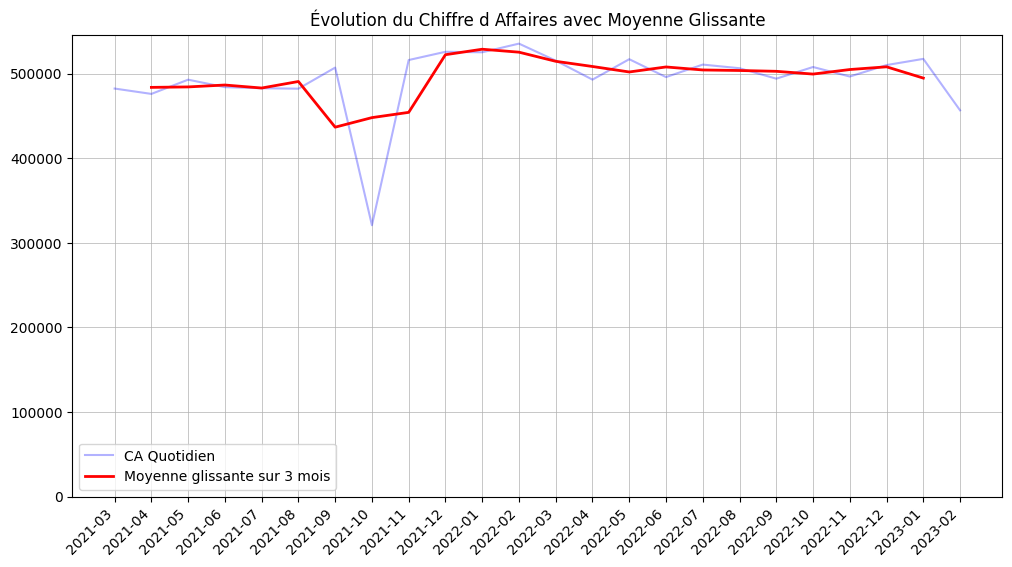

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(df_CA_rolling['date'], df_CA_rolling['CA'], label='CA Quotidien', alpha=0.3, color='blue')
plt.plot(df_CA_rolling['date'], df_CA_rolling['CA_rolling_3'], label='Moyenne glissante sur 3 mois', color='red', linewidth=2)
plt.grid(lw=0.5)
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, 600000, 100000))
plt.title('Évolution du Chiffre d Affaires avec Moyenne Glissante')
plt.legend()
plt.show()

CA constant autour de 500k par mois. Grosse Baisse de CA sur le mois d'octobre 2021. Pourqoi ? !

In [50]:
print(f"Ca total depuis ouverture : {df_CA_rolling['CA'].sum():.2f}€.")

Ca total depuis ouverture : 11853728.68€.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Chiffre d’affaires par catégorie</h3>
</div>

In [51]:
# On crée un DF pour avoir le CA / mois / catégorie
df_CA_categ = df_final_date_formate.groupby(by=['categ', 'date'])['CA'].sum().reset_index()

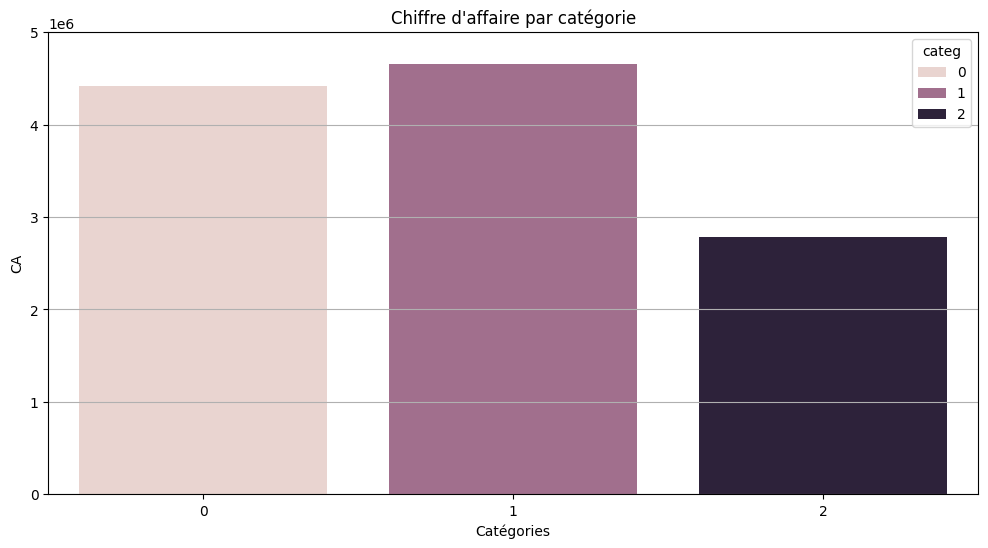

In [52]:
# On fait un premier graph pour avoir la somme des 3 categ

plt.figure(figsize=(12, 6))
sns.barplot(x=df_CA_categ['categ'], y=df_CA_categ['CA'], hue=df_CA_categ['categ'], estimator='sum', errorbar=None)
plt.title("Chiffre d'affaire par catégorie")
plt.xlabel("Catégories")
plt.yticks(range(0, 6000000, 1000000))
plt.ylabel("CA")
plt.grid(axis='y')
plt.show()

catégorie 1 domine le CA.

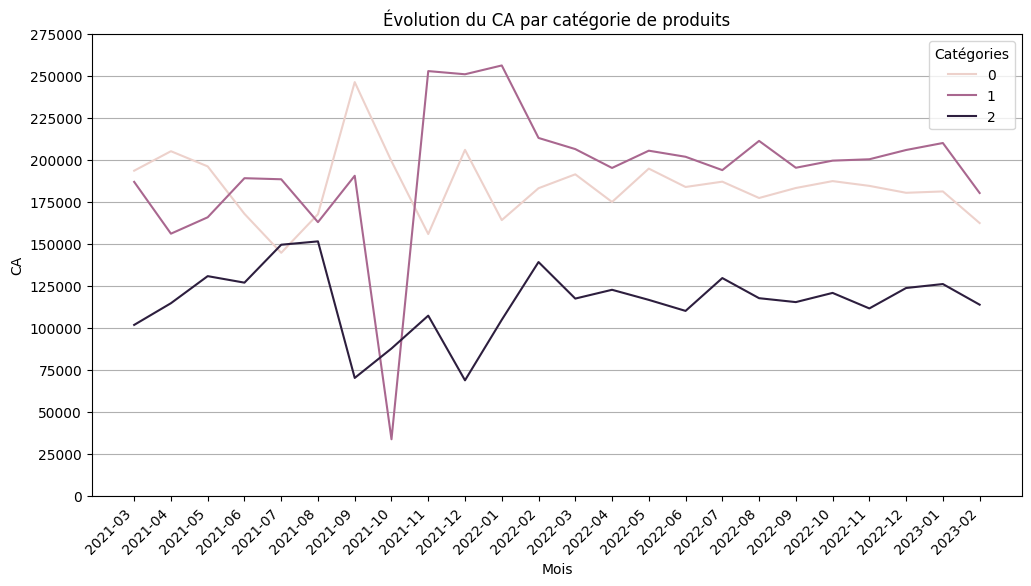

In [53]:
# Un autre pour avoir l'évolution au fil du temps

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_CA_categ, x='date', y='CA', hue='categ')
plt.yticks(range(0, 300000, 25000))
plt.title('Évolution du CA par catégorie de produits')
plt.grid(axis='y')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Mois")
plt.legend(title='Catégories')
plt.show()


Grosse perte de CA en catégorie 1  : ceci explique mieux la perte de CA global en octobre 2021.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.3 - Nombre de clients par mois</h3>
</div>

In [54]:
# On va d'abord créer un df pour avoir le nombre de clients unique par mois
df_clients_uniques = df_final_date_formate.groupby('date')['client_id'].nunique().reset_index()

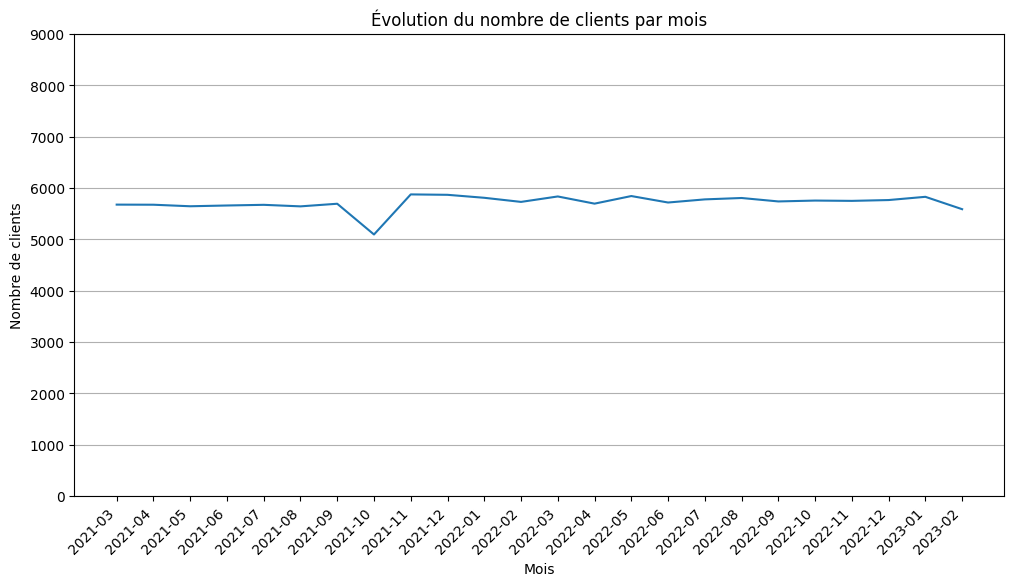

In [55]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clients_uniques, x='date', y='client_id')
plt.title('Évolution du nombre de clients par mois')
plt.grid(axis='y')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, 10000, 1000))
plt.xlabel("Mois")
plt.ylabel("Nombre de clients")
plt.show()

Toujours un trou en octobre 2010. sinon la courbe est stable

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.4 - Nombre de transactions</h3>
</div>

In [56]:
# On va d'abord créer un df pour avoir le nombre de transactions(paniers) uniques par mois
df_transactions_total = df_final_date_formate.groupby('date')['session_id'].nunique().reset_index()
df_transactions_total.rename(columns={'session_id': 'total'}, inplace=True)

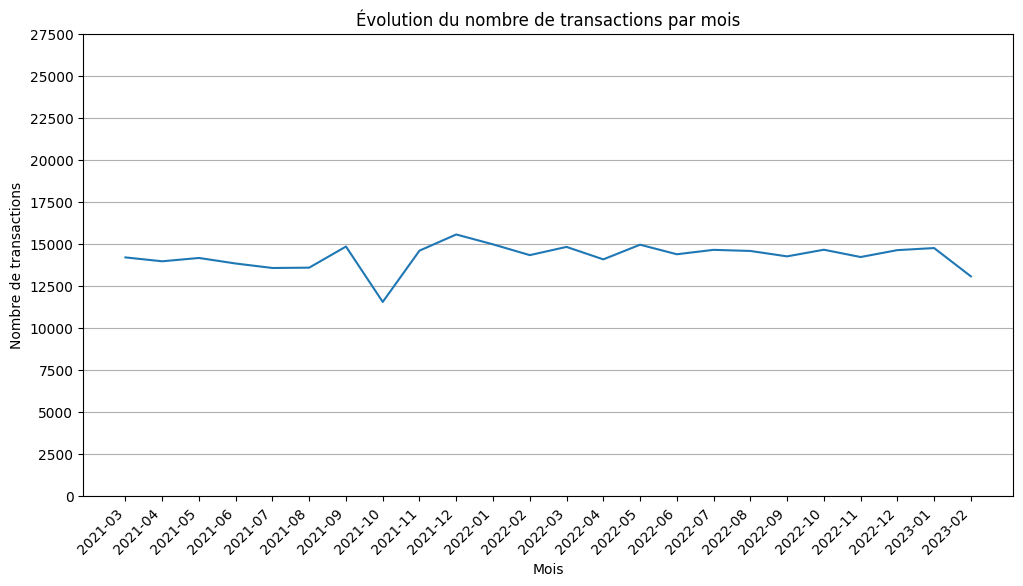

In [57]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_transactions_total, x='date', y='total')
plt.title('Évolution du nombre de transactions par mois')
plt.grid(axis='y')
plt.yticks(range(0, 30000, 2500))
plt.xticks(rotation=45, ha='right')
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.show()

Ici aussi courbe stable autour des 15k, toujours une baisse en 10/21.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.5 - Nombre de produits vendus</h3>
</div>

In [58]:
# On va d'abord créer un df pour avoir le nombre de produits vendus par mois
df_produits_uniques = df_final_date_formate.groupby('date')['id_prod'].count().reset_index()

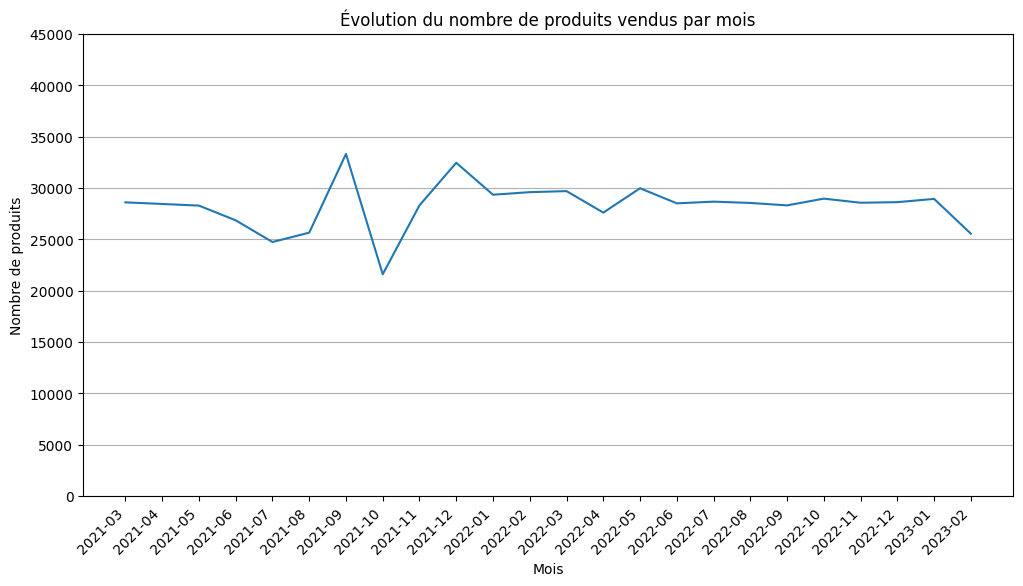

In [59]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_produits_uniques, x='date', y='id_prod')
plt.title('Évolution du nombre de produits vendus par mois')
plt.grid(axis='y')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, 50000, 5000))
plt.xlabel("Mois")
plt.ylabel("Nombre de produits")
plt.show()

Mêmes observations que sur les grpahs précédents même si on voit un pic de conso le mois précédent. le "trou" en oct est peut être dû à une rupture de stock.

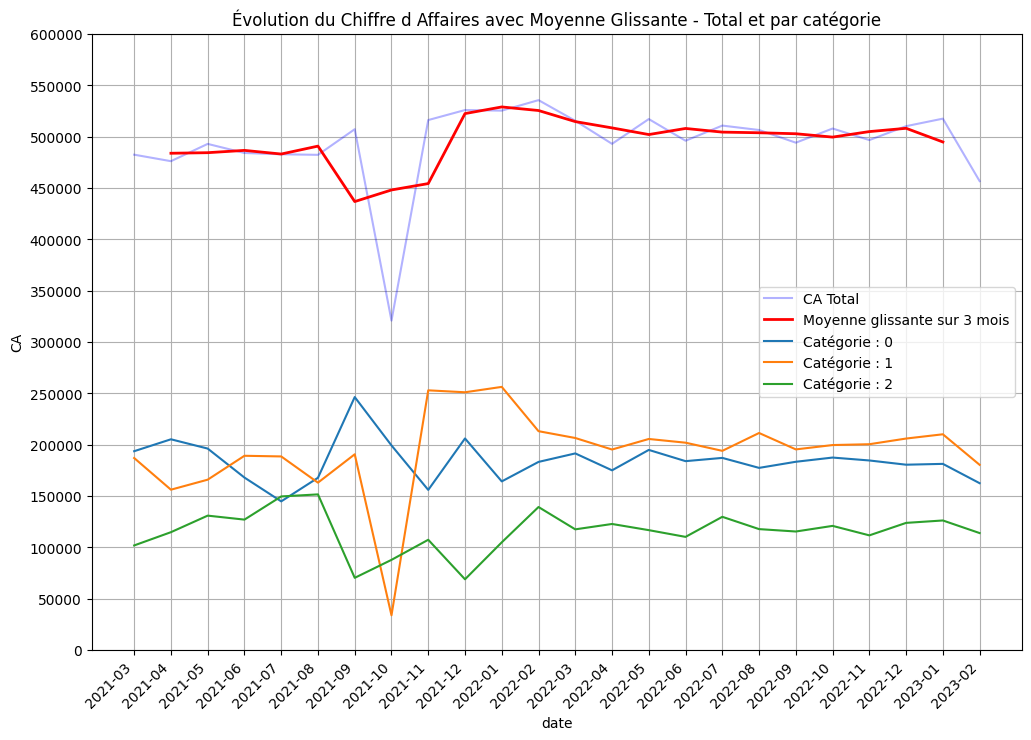

In [60]:
#On va récpituler nos observations sur deux graphs:

# Ajout d'un label sur les catégories pour plus de lisibilité sur le graph
df_CA_categ['categ_label'] = "Catégorie : " + df_CA_categ['categ'].astype(str)

plt.figure(figsize=(12, 8))
plt.plot(df_CA_rolling['date'], df_CA_rolling['CA'], label='CA Total', alpha=0.3, color='blue')
plt.plot(df_CA_rolling['date'], df_CA_rolling['CA_rolling_3'], label='Moyenne glissante sur 3 mois', color='red', linewidth=2)
sns.lineplot(data=df_CA_categ, x='date', y='CA', hue='categ_label')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0,650000, 50000))
plt.grid("x")
plt.title('Évolution du Chiffre d Affaires avec Moyenne Glissante - Total et par catégorie')
plt.legend()
plt.show()

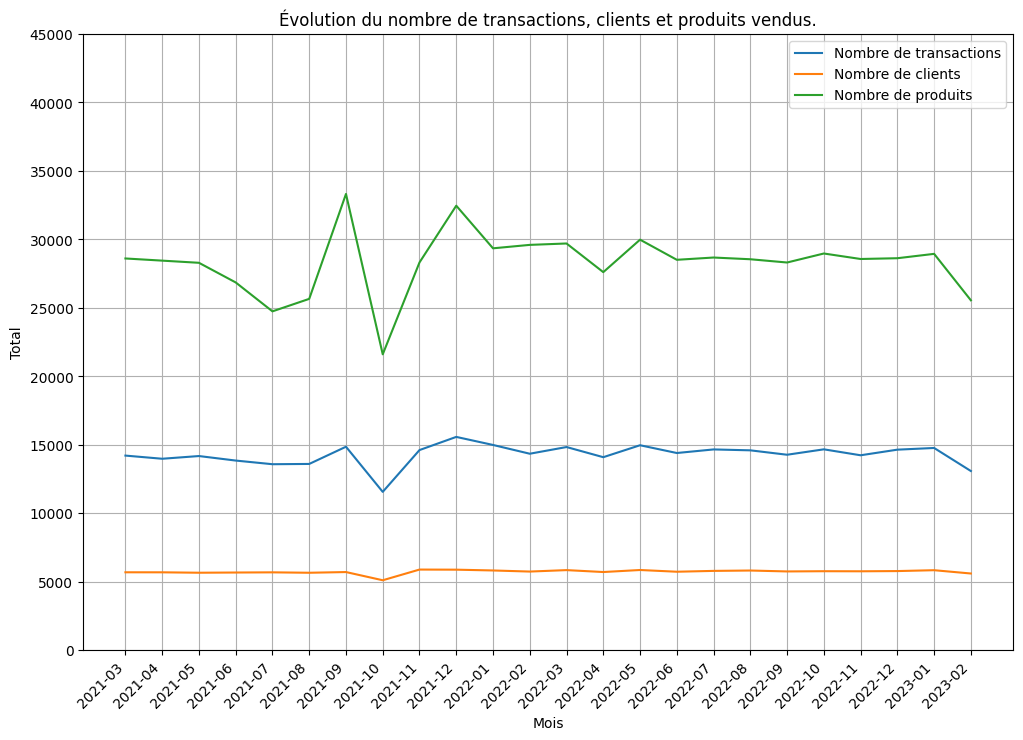

In [61]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=df_transactions_total, x='date', y='total', label = 'Nombre de transactions')
sns.lineplot(data=df_clients_uniques, x='date', y='client_id', label = 'Nombre de clients')
sns.lineplot(data=df_produits_uniques, x='date', y='id_prod', label = 'Nombre de produits')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0,50000, 5000))
plt.grid("x")
plt.ylabel("Total")
plt.xlabel("Mois")
plt.title('Évolution du nombre de transactions, clients et produits vendus.')
plt.legend()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Zoom sur les références  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Les tops et flops</h3>
</div>

In [62]:
# On va d'abord créer un df pour avoir le CA de chaque référence
df_CA_prod = df_final_date_formate.groupby(by=['id_prod', 'categ'])['CA'].sum().reset_index()

In [63]:
df_CA_prod_top_5 = df_CA_prod.sort_values(by='CA', ascending=False).reset_index().head(5)
df_CA_prod_flop_5 = df_CA_prod.sort_values(by='CA', ascending=False).reset_index().tail(5)

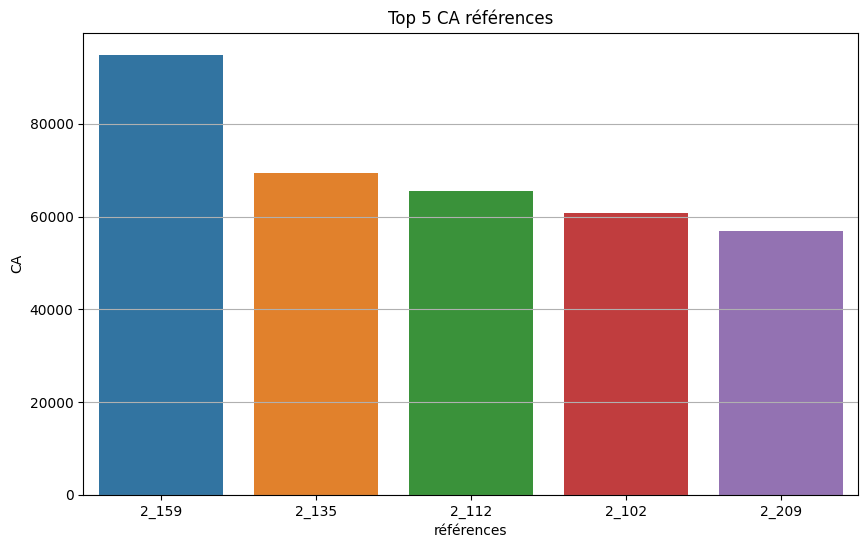

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(x=df_CA_prod_top_5['id_prod'], y=df_CA_prod_top_5['CA'], hue=df_CA_prod_top_5['id_prod'])
plt.title("Top 5 CA références")
plt.xlabel("références")
plt.ylabel("CA")
plt.grid(axis='y')
plt.show()

Toutes les refs commencent par "2".

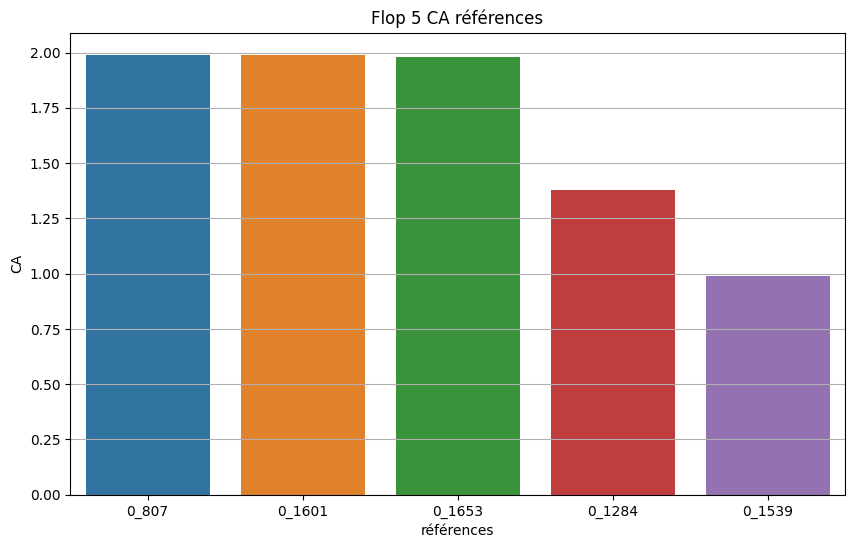

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(x=df_CA_prod_flop_5['id_prod'], y=df_CA_prod_flop_5['CA'], hue=df_CA_prod_flop_5['id_prod'])
plt.title("Flop 5 CA références")
plt.xlabel("références")
plt.ylabel("CA")
plt.grid(axis='y')
plt.show()

toutes commencent par "0".

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Répartition par catégories.</h3>
</div>

In [66]:
df_CA_prod

,id_prod,categ,CA
0,0_0,0,4657.50
1,0_1,0,5352.13
2,0_10,0,394.90
3,0_100,0,61.80
4,0_1000,0,2954.88
...,...,...,...
3260,2_95,2,395.96
3261,2_96,2,28650.18
3262,2_97,2,2092.87
3263,2_98,2,149.74


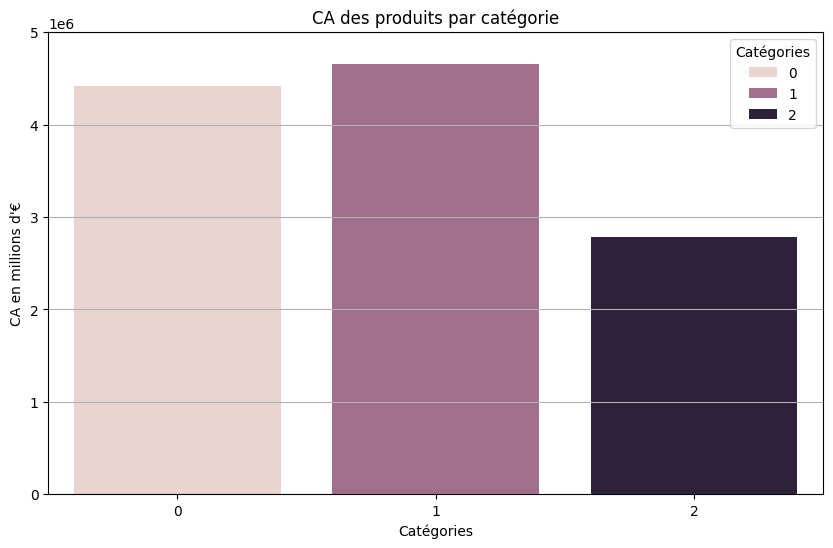

In [67]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_CA_prod, x='categ', y='CA', hue='categ', estimator='sum', errorbar=None)
plt.title("CA des produits par catégorie")
plt.yticks(range(0, 6000000, 1000000))
plt.ylabel("CA en millions d'€")
plt.xlabel("Catégories")
plt.legend(title = 'Catégories')
plt.grid(axis='y')
plt.show()

In [68]:
df_CA_prod_top_categ_0 = df_CA_prod[df_CA_prod['categ'] == 0].sort_values(by='CA', ascending=False).reset_index().head(3)
df_CA_prod_top_categ_1 = df_CA_prod[df_CA_prod['categ'] == 1].sort_values(by='CA', ascending=False).reset_index().head(3)
df_CA_prod_top_categ_2 = df_CA_prod[df_CA_prod['categ'] == 2].sort_values(by='CA', ascending=False).reset_index().head(3)
df_CA_prod_top_categ = pd.concat([df_CA_prod_top_categ_0,df_CA_prod_top_categ_1,df_CA_prod_top_categ_2])
df_CA_prod_top_categ

,index,id_prod,categ,CA
0,487,0_1441,0,23452.65
1,465,0_1421,0,23008.49
2,457,0_1414,0,22287.00
0,2619,1_395,1,54356.25
1,2591,1_369,1,54025.48
2,2641,1_414,1,51949.40
0,3096,2_159,2,94893.50
1,3070,2_135,2,69334.95
2,3045,2_112,2,65407.76


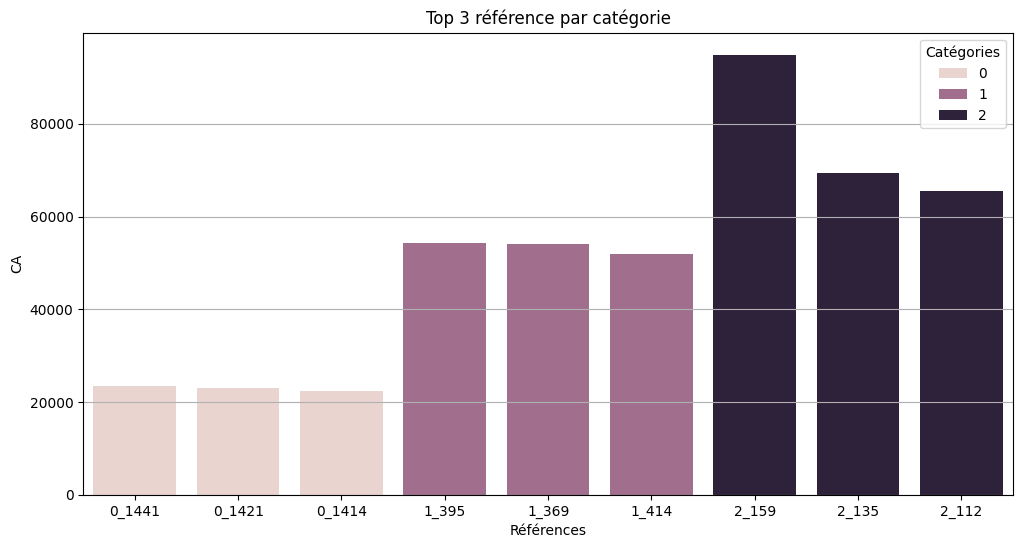

In [69]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df_CA_prod_top_categ['id_prod'], y=df_CA_prod_top_categ['CA'], hue=df_CA_prod_top_categ['categ'])
plt.title("Top 3 référence par catégorie")
plt.xlabel("Références")
plt.ylabel("CA")
plt.legend(title = 'Catégories')
plt.grid(axis='y')
plt.show()

In [70]:
# On va d'abord créer un df pour avoir le nombre de références par catégories
df_total_ref_categ = df_final_date_formate.groupby(by='categ')['id_prod'].nunique().reset_index()

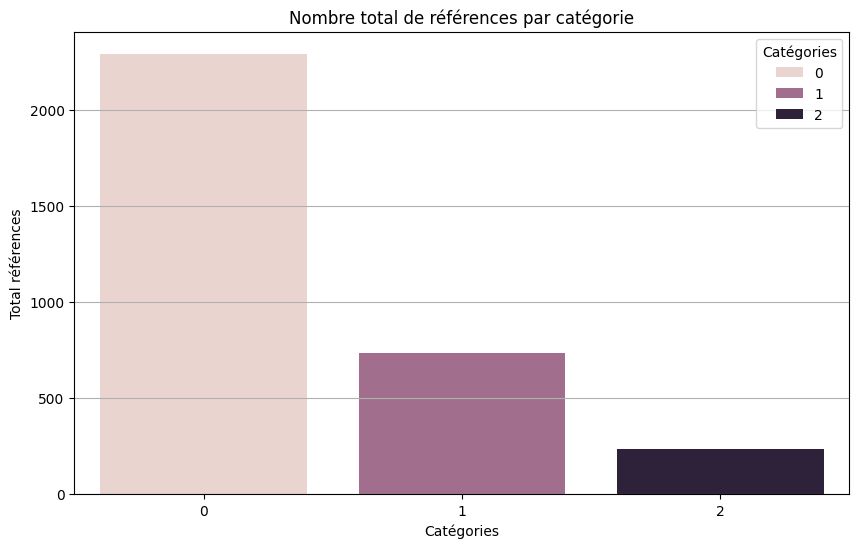

In [71]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_total_ref_categ['categ'], y=df_total_ref_categ['id_prod'], hue=df_total_ref_categ['categ'])
plt.title("Nombre total de références par catégorie")
plt.ylabel("Total références")
plt.xlabel("Catégories")
plt.legend(title = 'Catégories')
plt.grid(axis='y')
plt.show()

beaucoup de refs en caté 0(~2300), la catégorie 2 a très peu de références (~200)

In [72]:
#Allons voir le prix moyen des produits apr catégories
df_medium_price_categ = df_products.groupby(by='categ')['price'].mean().reset_index()

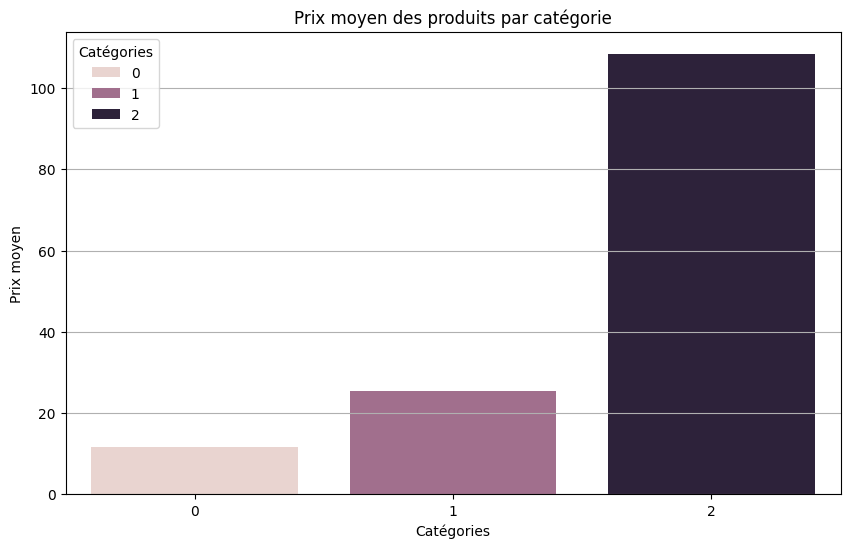

In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_medium_price_categ['categ'], y=df_medium_price_categ['price'], hue=df_medium_price_categ['categ'])
plt.title("Prix moyen des produits par catégorie")
plt.ylabel("Prix moyen")
plt.xlabel("Catégories")
plt.legend(title = 'Catégories')
plt.grid(axis='y')
plt.show()

caté 0 : petits produits peu chers (livres poches ou autres).  caté 1 : probablement des livres grands formats. caté 2 : prix moyen 100€, ce sont surement des livres de grandes qualité.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse des clients  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse du comportement d'achat.</h3>
</div>

In [74]:
df_CA_customers = df_final_date_formate.groupby('client_id').agg({'CA': 'sum','id_prod': 'count'}).reset_index()

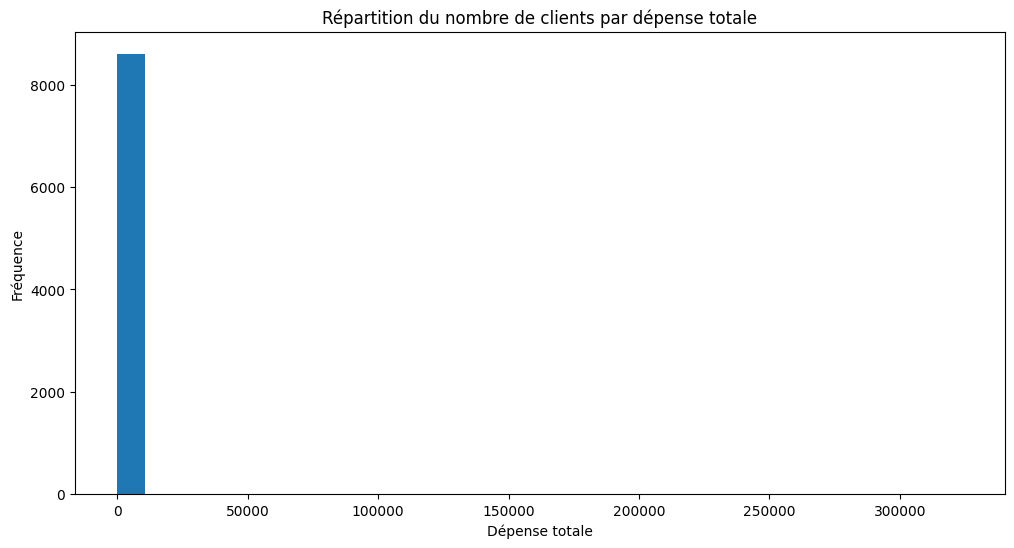

In [75]:
plt.figure(figsize=(12, 6))
plt.hist(df_CA_customers['CA'], bins=30)
plt.title('Répartition du nombre de clients par dépense totale')
plt.xlabel('Dépense totale')
plt.xticks()
plt.ylabel('Fréquence')
plt.show()

Il semble qu'on ait des clients qui dépensent beaucoup plus que d'autres (+300k €).

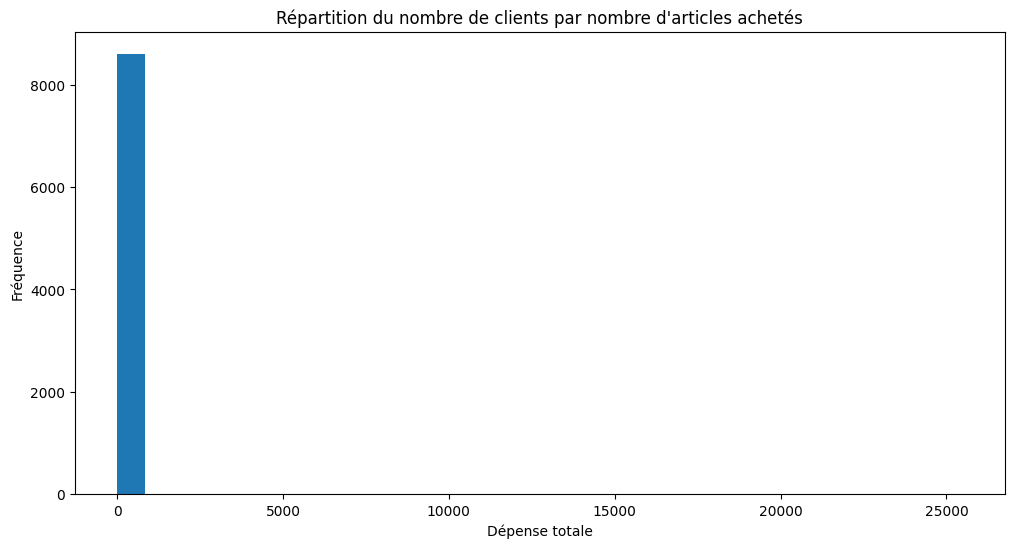

In [76]:
plt.figure(figsize=(12, 6))
plt.hist(df_CA_customers['id_prod'], bins=30)
plt.title('Répartition du nombre de clients par nombre d\'articles achetés')
plt.xlabel('Dépense totale')
plt.xticks()
plt.ylabel('Fréquence')
plt.show()

Il semble qu'on ait des clients qui achètent de plus gros volume.

In [77]:
def detect_outliers(df, feature):
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3-q1
    out_bas = (q1 -2*iqr)
    out_haut = (q3 + 2*iqr)

    return [((df[feature] < out_bas) | (df[feature] > out_haut)), iqr, out_bas, out_haut]

outliers_CA = detect_outliers(df_CA_customers, 'CA')

print(f"Le seuil de CA pour les clients outliers est de {outliers_CA[3]:.2f}€.")

Le seuil de CA pour les clients outliers est de 4243.24€.


In [78]:
df_CA_customers_BTB = df_CA_customers[(df_CA_customers['CA'] >= 4243.24)]

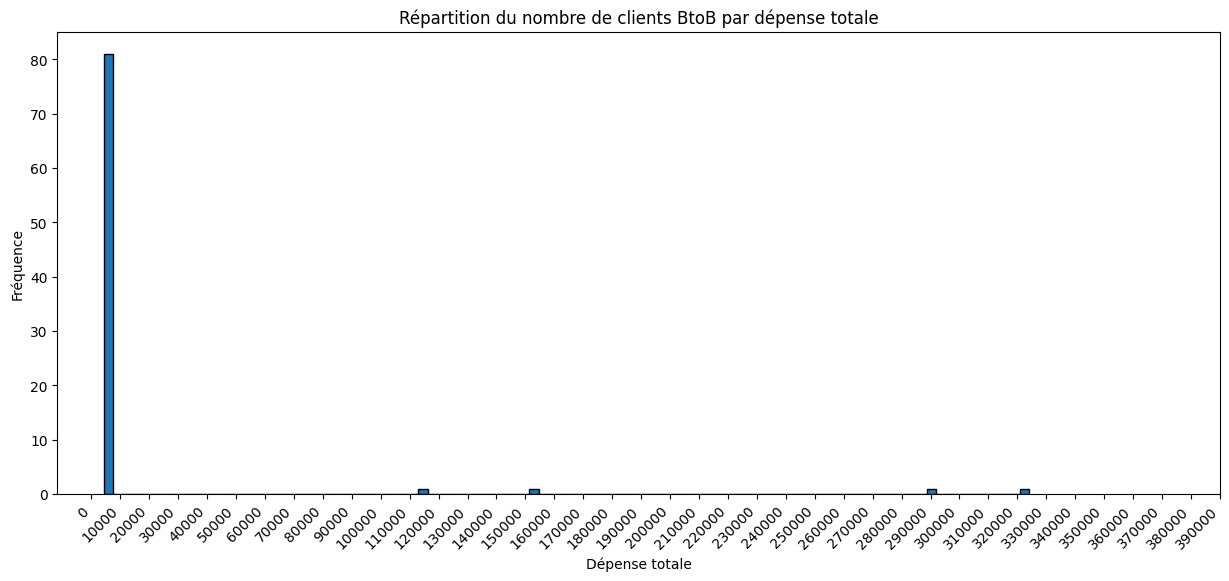

In [79]:
plt.figure(figsize=(15, 6))
plt.hist(df_CA_customers_BTB['CA'], bins=100, edgecolor='black')
plt.title('Répartition du nombre de clients BtoB par dépense totale')
plt.xlabel('Dépense totale')
plt.xticks(range(0,400000, 10000), rotation=45, ha='right')
plt.xticks()
plt.ylabel('Fréquence')
plt.show()

On va fixer un seuil à 10000 pour séparer les btob des btoc.

In [80]:
df_CA_customers_BTB = df_CA_customers[df_CA_customers['CA'] >= 10000]
df_CA_customers_BTC = df_CA_customers[df_CA_customers['CA'] < 10000]

Moyenne des dépenses : 1276.4888483015354
Écart type des dépenses : 954.1822746196475


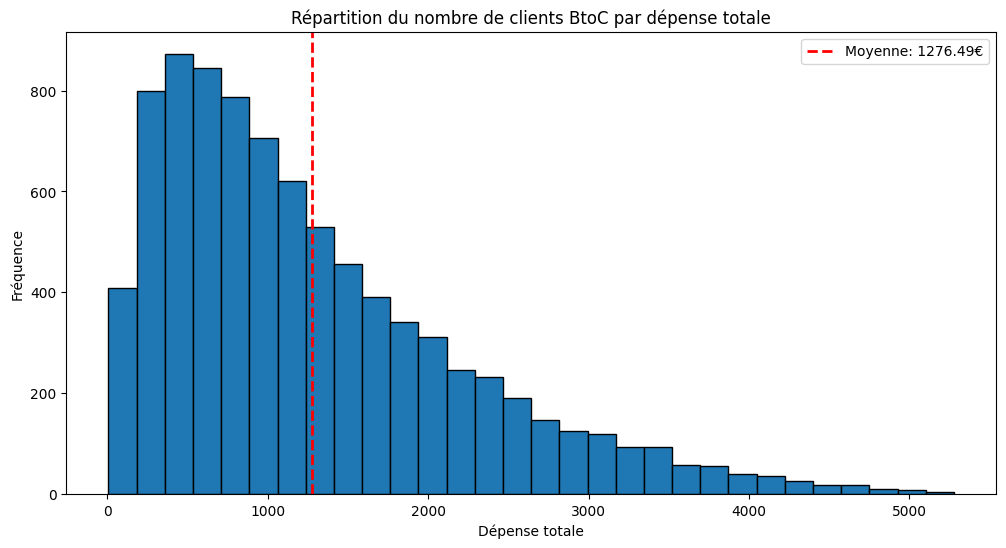

In [81]:
depense_totale = df_CA_customers_BTC['CA']

mean_depense_totale = depense_totale.mean()
std_depense_totale = depense_totale.std()

# Afficher les valeurs calculées
print(f"Moyenne des dépenses : {mean_depense_totale}")
print(f"Écart type des dépenses : {std_depense_totale}")

plt.figure(figsize=(12, 6))
plt.hist(df_CA_customers_BTC['CA'], bins=30, edgecolor='black')
plt.axvline(mean_depense_totale, color='red', linestyle='dashed', linewidth=2, label=f'Moyenne: {mean_depense_totale:.2f}€')
plt.title('Répartition du nombre de clients BtoC par dépense totale')
plt.xlabel('Dépense totale')
plt.xticks()
plt.ylabel('Fréquence')
plt.legend()
plt.show()

Ca total des clients B2B : 881030.54€.
 % du Ca total des clients B2B : 7.43%.


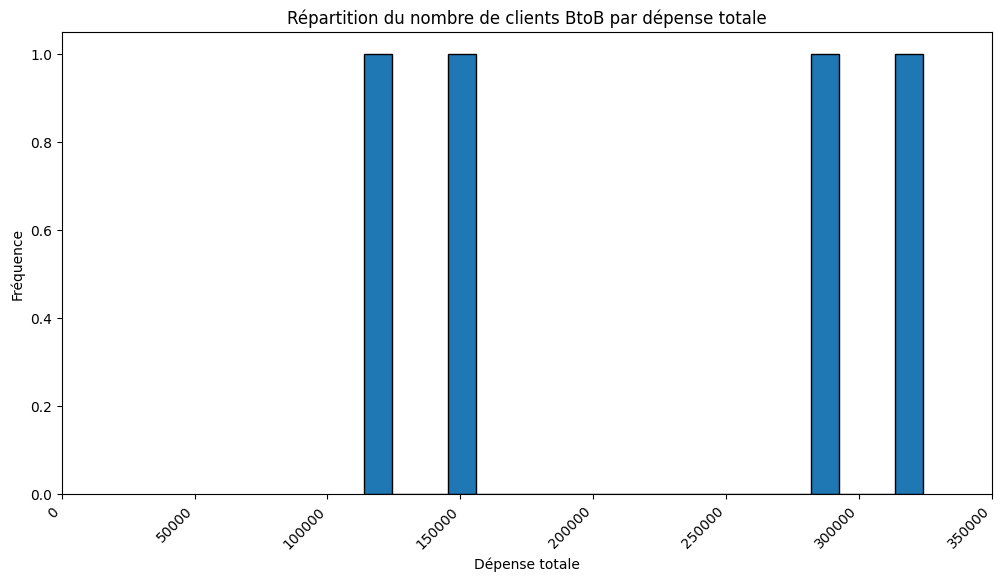

In [82]:
print(f"Ca total des clients B2B : {df_CA_customers_BTB['CA'].sum():.2f}€.")
print(f" % du Ca total des clients B2B : {(df_CA_customers_BTB['CA'].sum()*100/df_CA_rolling['CA'].sum()):.2f}%.")
      
plt.figure(figsize=(12, 6))
plt.hist(df_CA_customers_BTB['CA'], bins=20, edgecolor='black')
plt.title('Répartition du nombre de clients BtoB par dépense totale')
plt.xlabel('Dépense totale')
plt.xticks(range(0,400000, 50000), rotation=45, ha='right')
plt.xticks()
plt.ylabel('Fréquence')
plt.show()

In [83]:
df_CA_customers_BTB

,client_id,CA,id_prod
677,c_1609,324033.35,25488
2724,c_3454,113637.93,6770
4388,c_4958,289760.34,5195
6337,c_6714,153598.92,9181


On obtient 4 clients BTOB <br> On va donc garder que nos clients btc pour faire la suite de nos analyses car les BTB peuvent fausser les résultats.

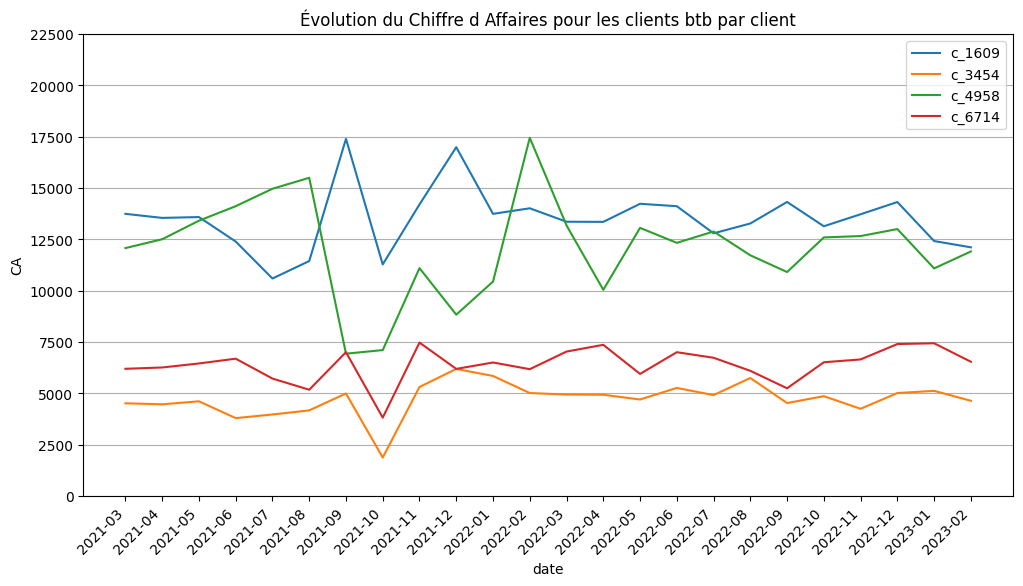

In [84]:
btb = df_CA_customers_BTB['client_id'].tolist()
df_ca_btb = df_final_date_formate[df_final_date_formate['client_id'].isin(btb)]

df_ca_btb = df_ca_btb.groupby(['date', 'client_id'])['CA'].sum().reset_index()
df_ca_btb.rename(columns={'total_panier': 'CA'}, inplace=True)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_ca_btb, x='date', y='CA', hue='client_id')
plt.xticks(rotation=45, ha='right',)
plt.grid(axis="y")
plt.yticks(range(0,25000, 2500))
plt.title('Évolution du Chiffre d Affaires pour les clients btb par client')
plt.legend()
plt.show()

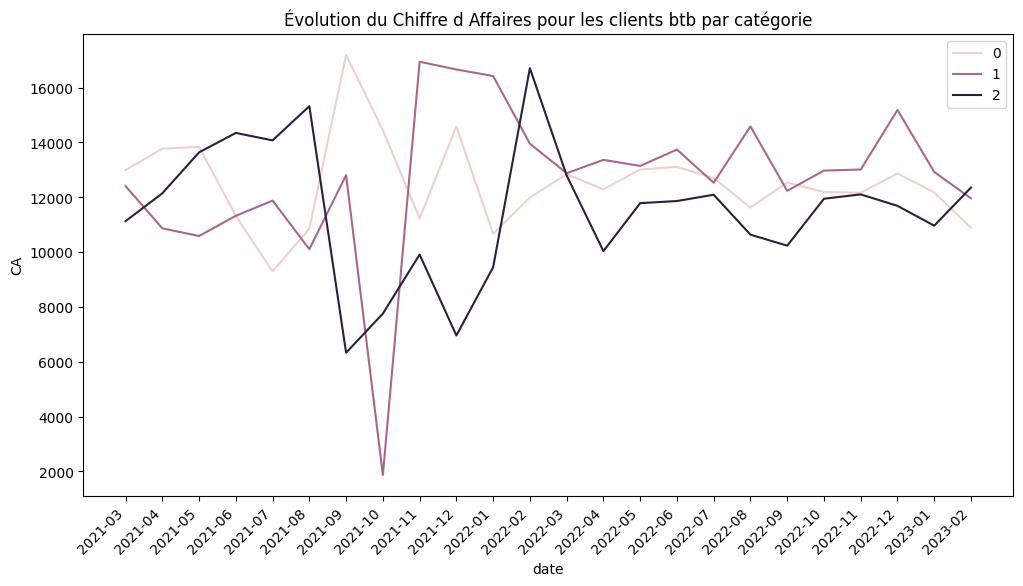

In [85]:
df_ca_categ_btb = df_final_date_formate[df_final_date_formate['client_id'].isin(btb)]
df_ca_categ_btb = df_ca_categ_btb.groupby(['date', 'categ'])['CA'].sum().reset_index()
df_ca_btb.rename(columns={'total_panier': 'CA'}, inplace=True)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_ca_categ_btb, x='date', y='CA', hue='categ')
plt.xticks(rotation=45, ha='right')
plt.title('Évolution du Chiffre d Affaires pour les clients btb par catégorie')
plt.legend()
plt.show()

Les clients b2b n'ont pas une catégorie de prédiléction.

95.5% des clients représentent 80% du CA.


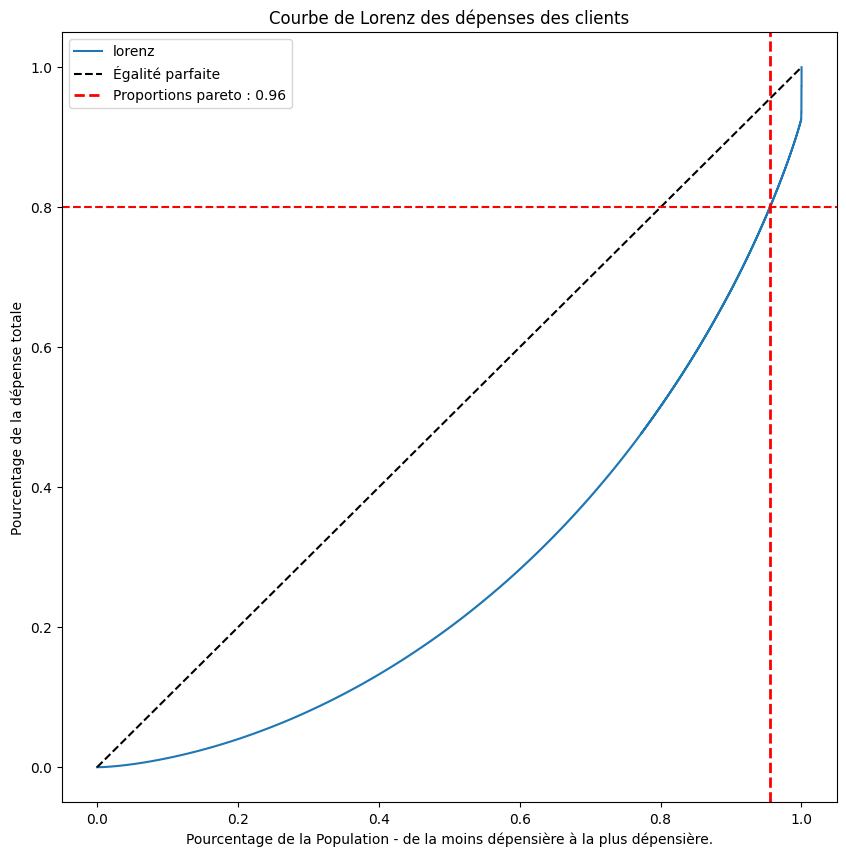

In [86]:
dep = df_CA_customers['CA'].values
n = len(dep)
lorenz = np.cumsum(np.sort(dep)) / dep.sum()
lorenz = np.append([0],lorenz)

index_80 = len([e for e in lorenz if e <= 0.8])
proportion_clients = index_80 / len(lorenz)

print(f"{proportion_clients:.1%} des clients représentent 80% du CA.")

xaxis = np.linspace(0-1/n,1+1/n,n+1) #Il y a un segment de taille n pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/n, et le dernier termine à 1+1/n.
plt.figure(figsize=(10, 10))
plt.plot(xaxis,lorenz,drawstyle='steps-post', label='lorenz')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Égalité parfaite')
plt.axvline(proportion_clients, color='red', linestyle='dashed', linewidth=2, label=f'Proportions pareto : {proportion_clients:.2f}')
plt.axhline(0.8, color='red', linestyle='dashed')
plt.title('Courbe de Lorenz des dépenses des clients')
plt.ylabel('Pourcentage de la dépense totale')
plt.xlabel('Pourcentage de la Population - de la moins dépensière à la plus dépensière.')
plt.legend()
plt.show()

Courbe peu bombée. En revanche, les 4 clients btob identifiés plus haut affectent la courbe sur la point 0.99 en une ligne verticale.

In [87]:
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/n # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S
print(f"L'indice de gini est de : {gini:.2f}")

L'indice de gini est de : 0.45


Cela indique que la surface entre la ligne en pointillé et la courbe recouvre 45% de l'espace situé en dessous de la ligne en pointillé. <br>
Cela  montre l'importance des clients B2B dans l'inégalité des dépenses parmi les clients de la libraire

92.9% des clients représentent 80% du CA.


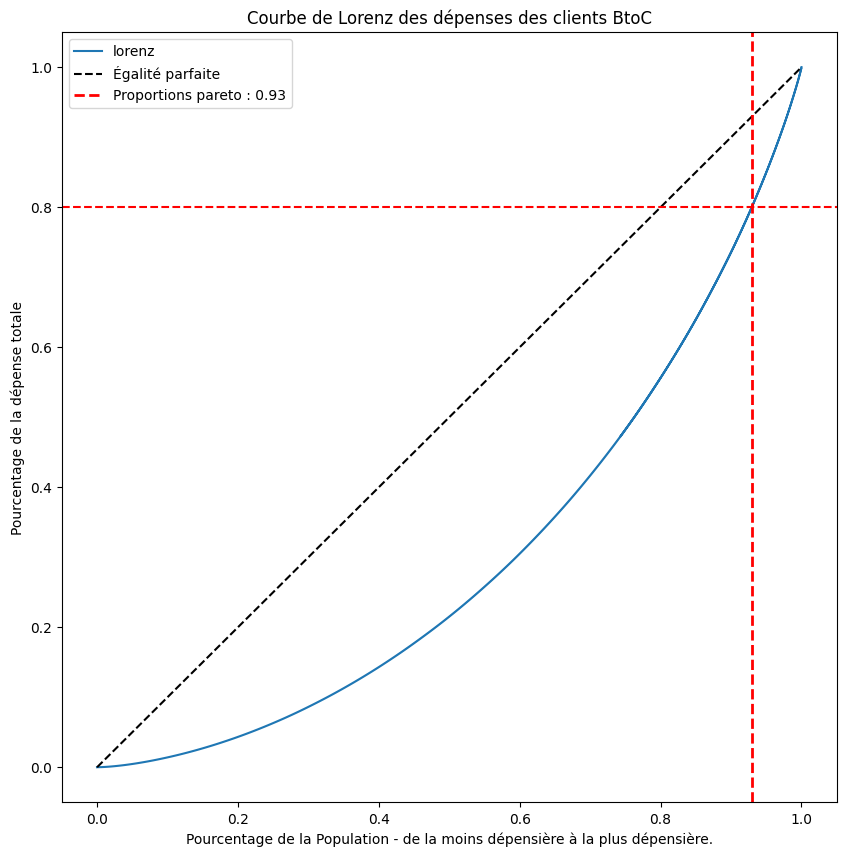

L'indice de gini est de : 0.40


In [88]:
dep = df_CA_customers_BTC['CA'].values
n = len(dep)
lorenz = np.cumsum(np.sort(dep)) / dep.sum()
lorenz = np.append([0],lorenz)

index_80 = len([e for e in lorenz if e <= 0.8])
proportion_clients = index_80 / len(lorenz)

print(f"{proportion_clients:.1%} des clients représentent 80% du CA.")

xaxis = np.linspace(0-1/n,1+1/n,n+1) #Il y a un segment de taille n pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/n, et le dernier termine à 1+1/n.
plt.figure(figsize=(10, 10))
plt.plot(xaxis,lorenz,drawstyle='steps-post', label='lorenz')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Égalité parfaite')
plt.axvline(proportion_clients, color='red', linestyle='dashed', linewidth=2, label=f'Proportions pareto : {proportion_clients:.2f}')
plt.axhline(0.8, color='red', linestyle='dashed')
plt.title('Courbe de Lorenz des dépenses des clients BtoC')
plt.ylabel('Pourcentage de la dépense totale')
plt.xlabel('Pourcentage de la Population - de la moins dépensière à la plus dépensière.')
plt.legend()
plt.show()
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/n # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S
print(f"L'indice de gini est de : {gini:.2f}")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse par age</h3>
</div>

In [89]:
# On crée un df sur lequel on regroupe chaque client avec son age et le montant total dépensé.
df_client = df_final_date_formate.groupby(['client_id', 'âge', 'sex', 'age_group']).agg({'CA': 'sum', 'id_prod': 'count'}).reset_index()
df_client = df_client[df_client['CA'] < 10000] # On enlève les clients btb
df_client.rename(columns={'id_prod': 'total_articles'}, inplace=True)

In [90]:
df_CA_customer_age = df_client.groupby('age_group').agg({'CA': 'sum','total_articles': 'count', 'client_id': 'nunique'}).reset_index()

In [91]:
df_CA_customer_age.rename(columns={'id_prod': 'total_articles', 'client_id': 'nb_clients_uniques'}, inplace=True)

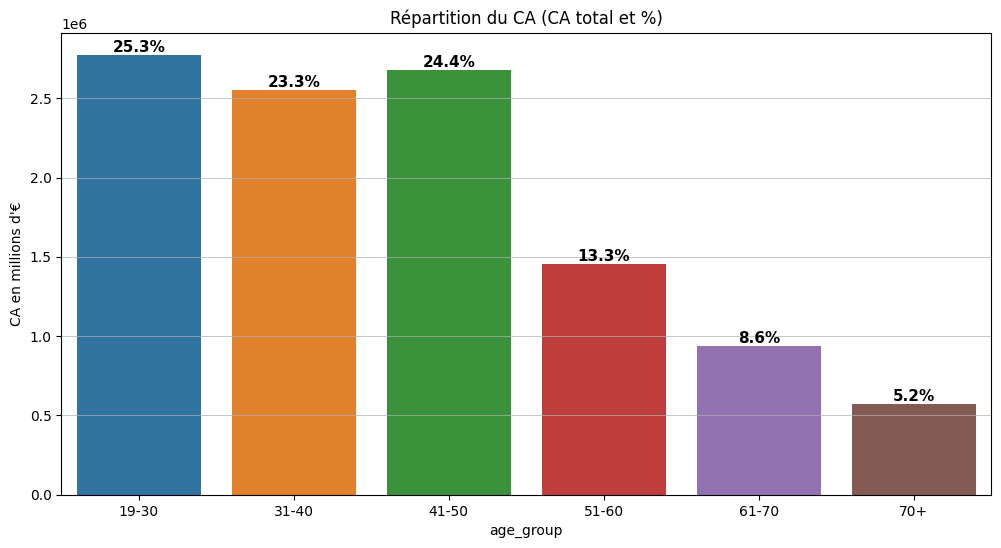

In [92]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=df_CA_customer_age['age_group'], y=df_CA_customer_age['CA'], hue=df_CA_customer_age['age_group'])

# Calcul du total pour les étiquettes
total = df_CA_customer_age['CA'].sum()

# Ajout automatique des pourcentages au-dessus des barres
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Répartition du CA (CA total et %)")
plt.grid(axis='y', lw=0.5)
plt.ylabel("CA en millions d'€")
plt.show()

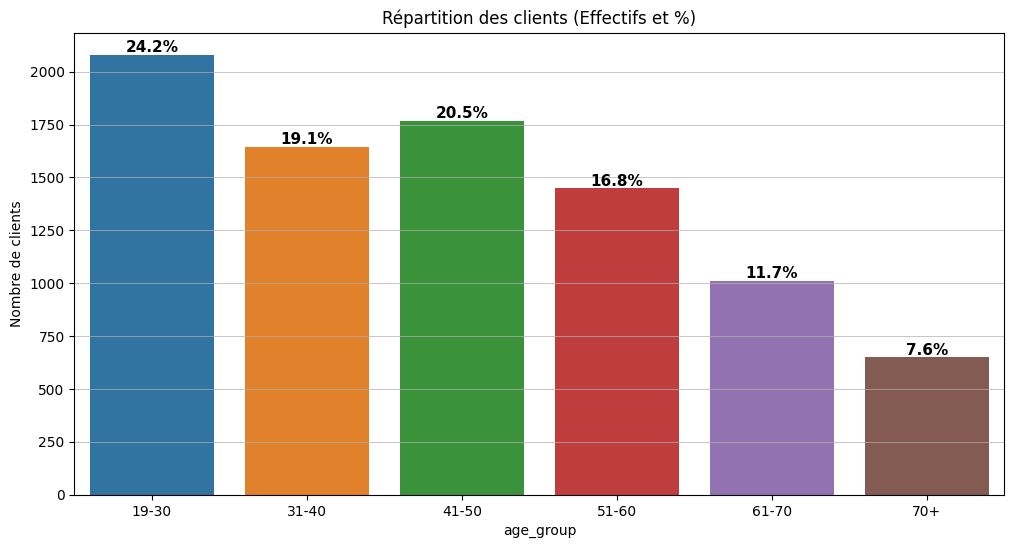

In [93]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_CA_customer_age, x='age_group', y='nb_clients_uniques', hue='age_group')

# Calcul du total pour les étiquettes
total = df_CA_customer_age['nb_clients_uniques'].sum()

# Ajout automatique des pourcentages au-dessus des barres
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Répartition des clients (Effectifs et %)")
plt.grid(axis='y', lw=0.5)
plt.ylabel("Nombre de clients")
plt.show()

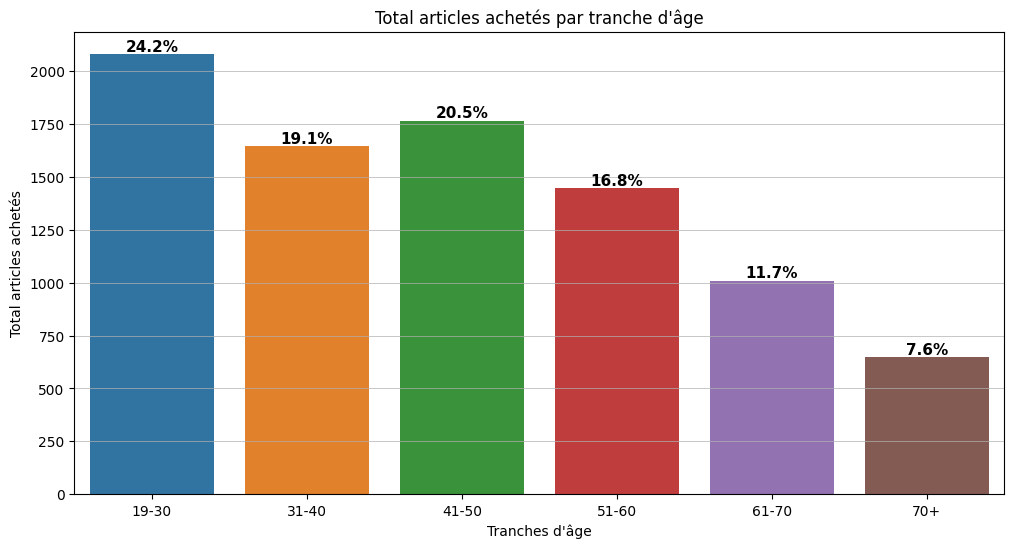

In [94]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=df_CA_customer_age['age_group'], y=df_CA_customer_age['total_articles'], hue=df_CA_customer_age['age_group'])

# Calcul du total pour les étiquettes
total = df_CA_customer_age['total_articles'].sum()

# Ajout automatique des pourcentages au-dessus des barres
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total articles achetés par tranche d\'âge')
plt.xlabel('Tranches d\'âge')
plt.ylabel('Total articles achetés')
plt.grid(axis='y', lw=0.5)
plt.show()

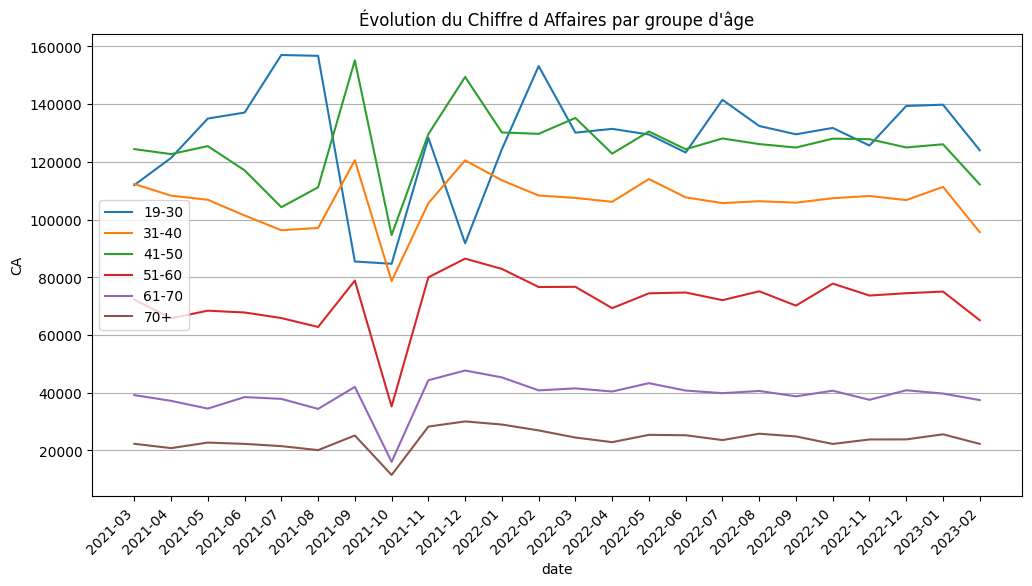

In [95]:
#Je crée un DF pour voir le CA par groupe d'age dans le temps.

df_final_date_formate_age_group = df_final_date_formate.groupby(['date', 'age_group'])['CA'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final_date_formate_age_group, x='date', y='CA', hue='age_group')
plt.xticks(rotation=45, ha='right')
plt.title('Évolution du Chiffre d Affaires par groupe d\'âge')
plt.grid(axis='y')
plt.legend()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse par sexe</h3>
</div>

In [96]:
# on crée un df pour aggréger nos donnés par genre en se servant du df_client qui ne possède pas les données btb

df_CA_customer_sex = df_client.groupby('sex').agg({'CA': 'sum','total_articles': 'sum'}).reset_index()
df_CA_customer_sex['sex'] = df_CA_customer_sex['sex'].str.upper()

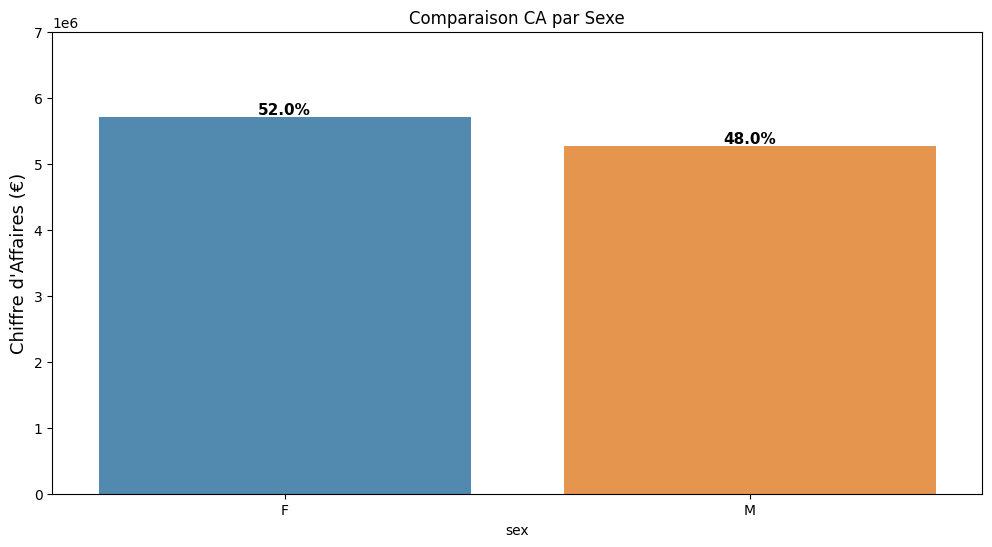

In [97]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_CA_customer_sex, x='sex', y='CA', alpha=0.6, hue='sex')

# Calcul du total pour les étiquettes
total = df_CA_customer_sex['CA'].sum()

# Ajout automatique des pourcentages au-dessus des barres
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

sns.barplot(data=df_CA_customer_sex, x='sex', y='CA', alpha=0.6, hue='sex')
plt.ylabel('Chiffre d\'Affaires (€)',  fontsize=13)
plt.yticks(range(0, 8000000, 1000000))
plt.title('Comparaison CA par Sexe')
plt.show()

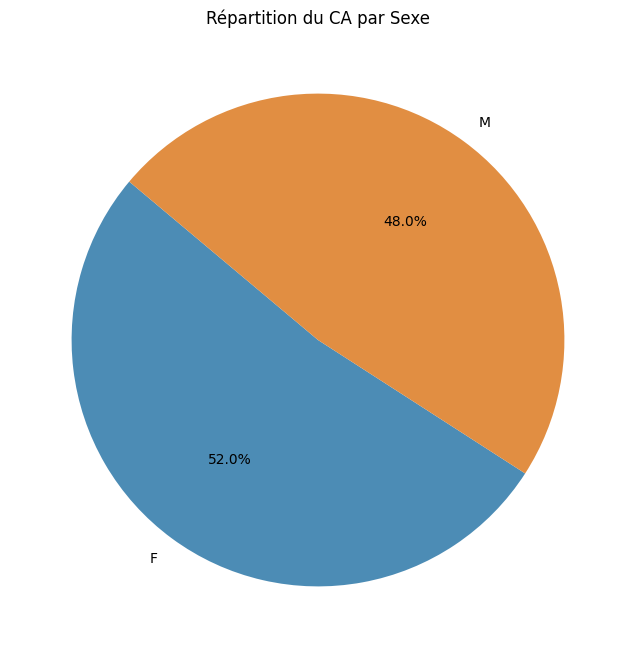

In [98]:
plt.figure(figsize=(8, 8))

labels = df_CA_customer_sex['sex']
sizes = df_CA_customer_sex['CA']
colors = ['#4c8cb5', '#e18e42']


plt.pie(sizes, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Répartition du CA par Sexe")
plt.show()

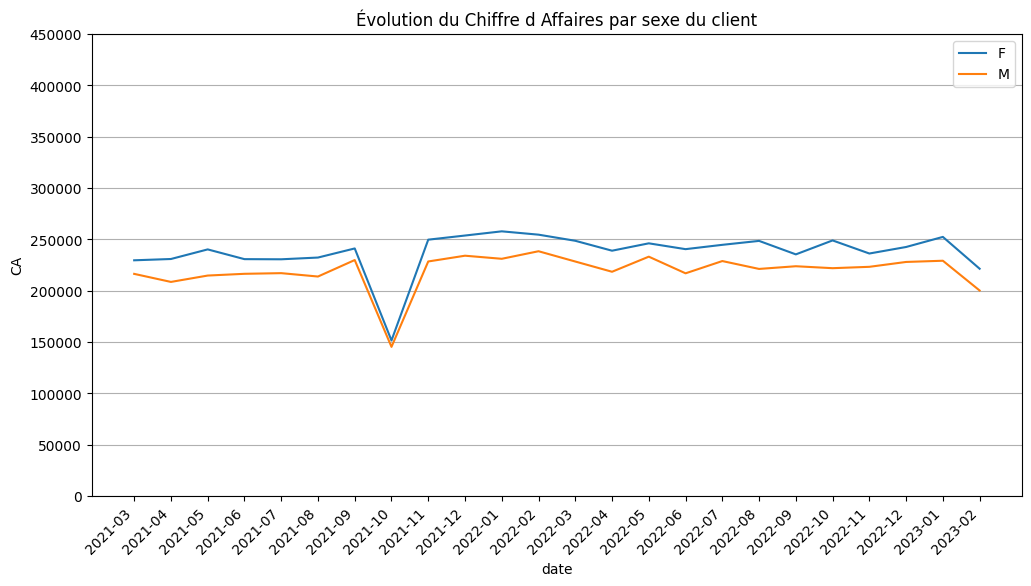

In [99]:
#Je crée un DF pour voir le CA par groupe d'age dans le temps, sans les btb !
df_CA_customer_sex_date = df_final_date_formate[~df_final_date_formate['client_id'].isin(btb)].groupby(['date', 'sex'])['CA'].sum().reset_index()
df_CA_customer_sex_date['sex'] = df_CA_customer_sex_date['sex'].str.upper() 

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_CA_customer_sex_date, x='date', y='CA', hue='sex')
plt.xticks(rotation=45, ha='right')
plt.title('Évolution du Chiffre d Affaires par sexe du client')
plt.grid(axis='y')
plt.yticks(range(0, 500000, 50000))
plt.legend()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse des corrélations  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.1 - Genre vs catégories</h3>
</div>

Le test du Chi-carré a été utilisé pour vérifier la dépendance entre legenre des clients et les catégories de produits achetés. Ce test est adapté pour
examiner les associations entre variables catégoriques dans de grands tableaux de contingence. <br>
Objectif de l'étude<br>
L'analyse visait à déterminer si les choix des produits varient en fonction du genre, une information utile pour orienter des offres et le marketing.

In [100]:
#Je crée un DF pour voir le CA par groupe d'age dans le temps, sans les btb !
df_b2c = df_final_date_formate[~df_final_date_formate['client_id'].isin(btb)].reset_index()
df_b2c['sex'] = df_b2c['sex'].str.upper() 

# Créer le tableau de contingence
contingency_table = pd.crosstab(df_b2c['sex'], df_b2c['categ'])

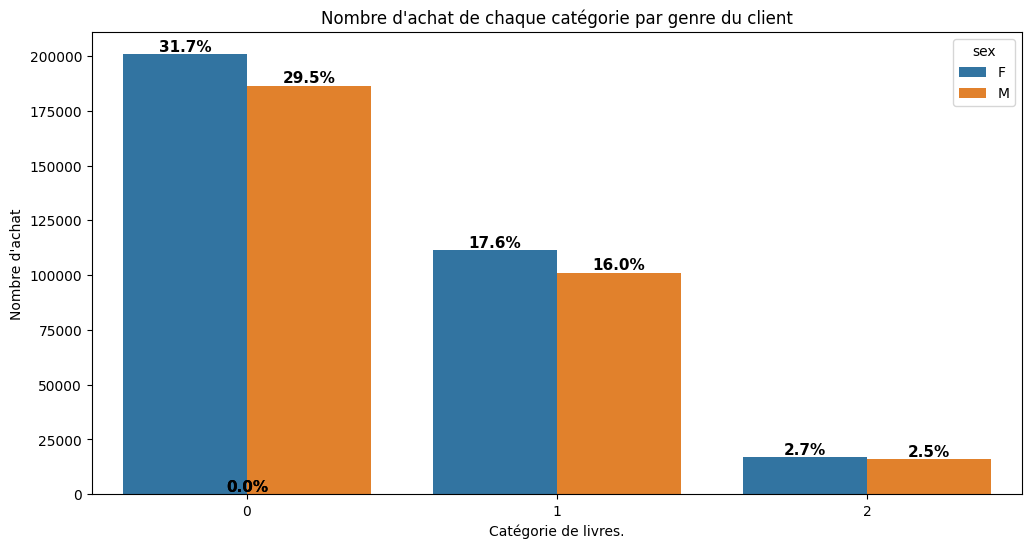

In [101]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df_b2c, x='categ', hue='sex')
# Calcul du total pour les étiquettes
total = len(df_b2c)

# Ajout automatique des pourcentages au-dessus des barres
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Nombre d'achat de chaque catégorie par genre du client")
plt.ylabel('Nombre d\'achat')
plt.xlabel('Catégorie de livres.')
plt.show()

In [102]:
# Calculer le test du Chi-2
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Statistique Chi-2: {chi2_stat}")
print(f"Valeur p: {p_value}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)
print("Fréquences réelles:")
display(contingency_table)

Statistique Chi-2: 20.213460693513895
Valeur p: 4.080400389217356e-05
Degrés de liberté: 2
Fréquences attendues:
[[201518.35754344 110493.46646914  17092.17598743]
 [185762.64245656 101854.53353086  15755.82401257]]
Fréquences réelles:


categ,0,1,2
sex,,,
F,200793,111331,16980
M,186488,101017,15868


Grands échantillons : Bien qu'ils puissent réduire l'erreur standard et rendre un test plus sensible aux petites différences, les grands échantillons peuvent aussi détecter des différences qui, bien que statistiquement significatives, sont pratiquement insignifiantes. Ceci peut conduire à des conclusions erronées sur l'importance des effets observés. À l'inverse de l’exemple précédent, un très grand échantillon pourrait détecter de petites différences qui, bien que statistiquement significatives, ne sont pas nécessairement importantes du point de vue commercial. Par exemple, une légère amélioration de la satisfaction client peut être détectée mais ne justifie pas un changement de stratégie coûteux.

Essais de Fischer pour chaque combianison de de 2 catégories.

In [ ]:
# catégorie 0 et 1



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.2 - Âge et montant</h3>
</div>

Le test de Spearman, un test de corrélation non paramétrique, a été utilisé pour comparer l'âge des clients et le montant total de leurs dépenses. Contrairement à Pearson, Spearman ne nécessite pas que les données soient normalement distribuées et est efficace pour analyser les relations monotones. <br>
Objectif de l'étude : <br>
Ce test visait à identifier si un âge plus avancé était associés à des dépenses plus élevées, une information clé pour adapter les offres en fonction de l'âge des clients.

Moyenne des dépenses : 44.739646347138205
Écart type des dépenses : 16.910541505897303
taille de mon échantillon : 8596
Statistique du test de Shapiro-Wilk : 0.9697306402580154
Valeur p : 4.615340399612398e-39
Les données ne suivent pas une distribution normale (on rejette H0)


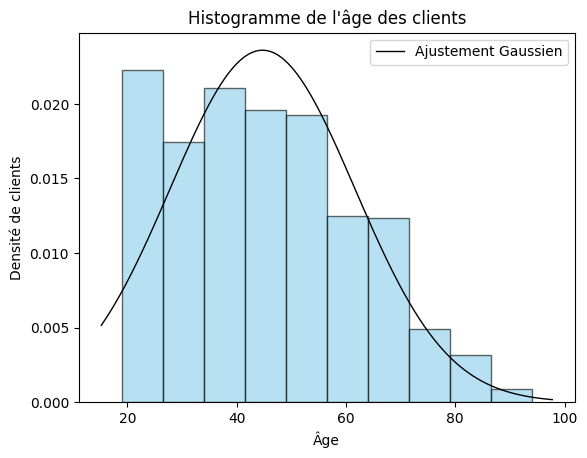

In [141]:
#On va vérifier si la variable age suit une loi normale en faisant un test de Shapiro-Wilk
age = df_client['âge']

# Calculer la moyenne et l'écart type
mean_age = age.mean()
std_age = age.std()

# Afficher les valeurs calculées
print(f"Moyenne des dépenses : {mean_age}")
print(f"Écart type des dépenses : {std_age}")

# Effectuer le test de Shapiro-Wilk
stat, p_value = shapiro(age)

# Afficher les résultats
print("taille de mon échantillon :", len(age))
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# H0 : la variable âge suit une distribution normale
# H1 : la variable âge ne suit pas une distribution normale

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

plt.hist(age, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(age)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, age.count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=1, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme de l\'âge des clients')
plt.xlabel('Âge')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

Ne suit pas une loi normale selon le test.

Moyenne des dépenses : 1276.4888483015357
Écart type des dépenses : 954.1822746196475
taille de mon échantillon : 8596
Statistique du test de Shapiro-Wilk : 0.9036921578731572
Valeur p : 1.1350044673532336e-58
Les données ne suivent pas une distribution normale (on rejette H0)


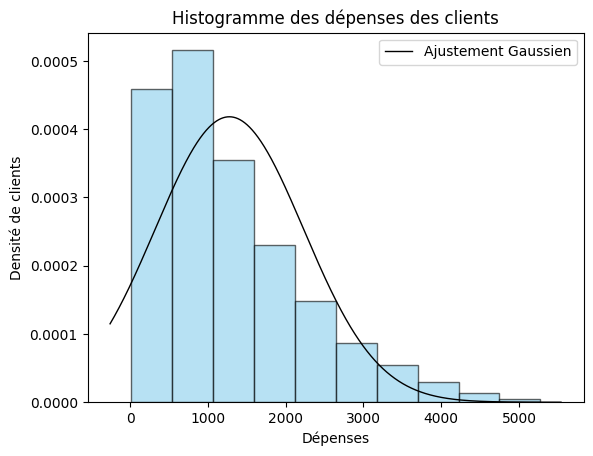

In [137]:
# Même test de Shapiro-wilk pour la variable dépenses 
depenses = df_client['CA']

# Calculer la moyenne et l'écart type
mean_depenses = depenses.mean()
std_depenses = depenses.std()

# Afficher les valeurs calculées
print(f"Moyenne des dépenses : {mean_depenses}")
print(f"Écart type des dépenses : {std_depenses}")

# Effectuer le test de Shapiro-Wilk 
stat, p_value = shapiro(depenses)

# Afficher les résultats
print("taille de mon échantillon :", len(depenses))
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# H0 : la variable âge suit une distribution normale
# H1 : la variable âge ne suit pas une distribution normale

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

plt.hist(depenses, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(depenses)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, depenses.count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=1, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme des dépenses des clients')
plt.xlabel('Dépenses')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

Ne suit pas une loi normale selon le test. On va donc préferer un test de Spearman (non paramétrique) au test de pearson.

Coefficient de corrélation de Spearman: -0.1851390805263805
Valeur p: 3.788264262141816e-67


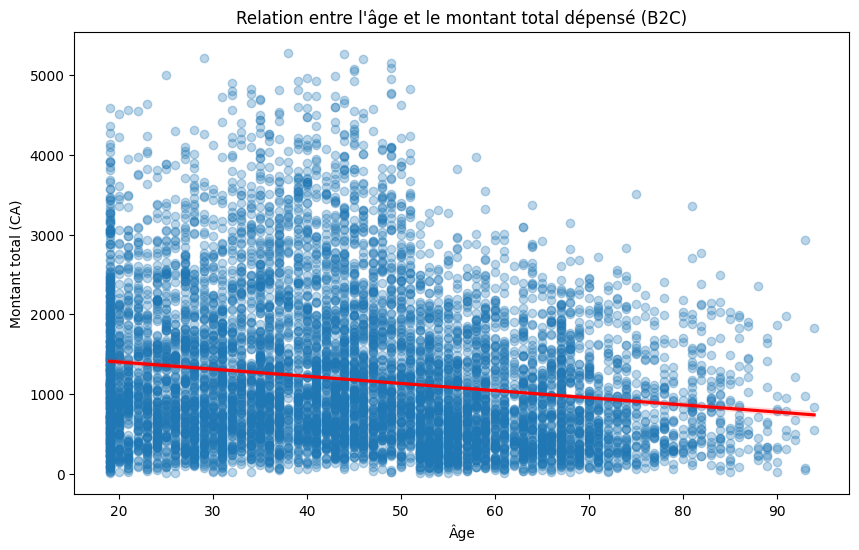

In [106]:
plt.figure(figsize=(10, 6))
sns.regplot(x='âge', y='CA', data=df_client, robust=True,
            scatter_kws={'alpha':0.3},
            line_kws={"color": "red"})

plt.title('Relation entre l\'âge et le montant total dépensé (B2C)')
plt.xlabel('Âge')
plt.ylabel('Montant total (CA)')

# Calculer le coefficient de corrélation de Spearman et p-alue
spearman_corr, spearman_p_value = spearmanr(age, depenses)

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

On observe une corrélation négative statistiquement significative (p<0.05), mais faible (r=−0.19). Cela montre que l'âge n'est pas le seul facteur explicatif du montant dépensé mais qu'il influence négativement le montant total dépensé. Nous allons utiliser les catégories d'âge des clients plutot que la variable discrète pour voir si les résultats sont plus probants.

L’ANOVA a été effectuée pour comparer le total de dépense des clients en fonction de leur catégorie d'âge. Ce test
est idéal pour comparer les moyennes de plusieurs groupes et évaluer les différences entre eux.
Objectif de l'étude
Cette analyse visait à identifier quel tranche d'âge génère le plus de dépenses chez les clients, permettant à Lapage de mieux connaitre sa clientelle et d'adapter les offres.

In [107]:
df_client = df_client.sort_values(by='age_group', ascending=True).reset_index()

Text(0, 0.5, 'Montant total (CA)')

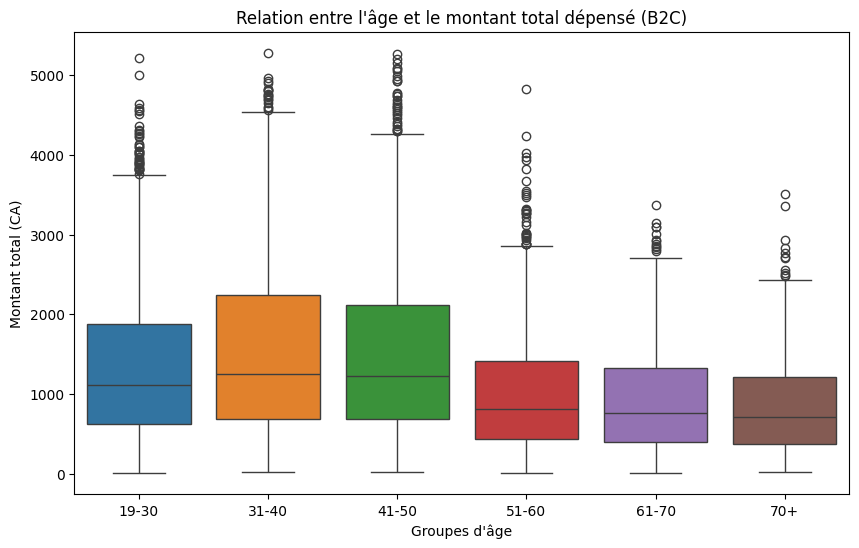

In [108]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='CA', data=df_client, hue='age_group')
plt.title('Relation entre l\'âge et le montant total dépensé (B2C)')
plt.xlabel('Groupes d\'âge')
plt.ylabel('Montant total (CA)')

Le groupe 19-30 : Ce sont nos clients les plus nombreux mais ils achètent moins que les 31-50

Le pic de dépense (31-50 ans) : Ce sont tes clients les plus dépensiers. Les médianes et les boîtes sont plus hautes.

À partir de 50 ans, les dépenses sont clairement plus faibles avec des médianes sous les 1000 €. 

In [151]:
# Sélectionner les colonnes pertinentes pour chaque catégorie
age_ca_19_30 = df_client[df_client['age_group'] == '19-30']['CA'].dropna()
age_ca_31_40 = df_client[df_client['age_group'] == '31-40']['CA'].dropna()
age_ca_41_50 = df_client[df_client['age_group'] == '41-50']['CA'].dropna()
age_ca_51_60 = df_client[df_client['age_group'] == '51-60']['CA'].dropna()
age_ca_61_70 = df_client[df_client['age_group'] == '61-70']['CA'].dropna()
age_ca_70_plus = df_client[df_client['age_group'] == '70+']['CA'].dropna()

# Calcul du test de Levene pour valider la possibilité d'Anova
stat_levene, p_levene = levene(age_ca_19_30, age_ca_31_40, age_ca_41_50, 
                               age_ca_51_60, age_ca_61_70, age_ca_70_plus)

print(f"Statistique de Levene : {stat_levene}")
print(f"Valeur p (Levene) : {p_levene}")

# 2. Interprétation automatique
if p_levene < 0.05:
    print("Résultat : Les variances sont significativement différentes (Hétéroscédasticité).")
    print("Conseil : L'ANOVA classique est risquée. Utilise l'ANOVA de Welch.")
else:
    print("Résultat : Les variances sont homogènes. L'ANOVA classique est valide.")

# Calculer le test ANOVA et la valeur p
f_stat, p_value = f_oneway(age_ca_19_30, age_ca_31_40, age_ca_41_50, age_ca_51_60, age_ca_61_70, age_ca_70_plus)

print(f"Statistique de test F: {f_stat}")
print(f"Valeur p: {p_value}")

Statistique de Levene : 79.5405457395784
Valeur p (Levene) : 7.544112240711467e-82
Résultat : Les variances sont significativement différentes (Hétéroscédasticité).
Conseil : L'ANOVA classique est risquée. Utilise l'ANOVA de Welch.
Statistique de test F: 133.51670570771168
Valeur p: 1.019149402040536e-136


In [152]:
# Calculer le test ANOVA et la valeur p
f_stat, p_value = f_oneway(age_ca_19_30, age_ca_31_40, age_ca_41_50, age_ca_51_60, age_ca_61_70, age_ca_70_plus)

print(f"Statistique de test F: {f_stat}")
print(f"Valeur p: {p_value}")

Statistique de test F: 133.51670570771168
Valeur p: 1.019149402040536e-136


In [161]:
# Effectuer l'ANOVA de Welch
welch_anova = pg.welch_anova(data=df_client, dv='CA', between='age_group')

# Afficher les résultats
print(welch_anova)

      Source  ddof1        ddof2           F          p_unc       np2
0  age_group      5  3403.771039  158.385152  1.079010e-151  0.072112


Le boxplot permet de clairement voir une différence de CA en fonction de la catégorie d'âge . On s’attend donc à obtenir
quelque chose de significatif avec le test statistique.
La statistique de test F compare la variation entre les groupes à la variation au sein de chaque groupe. Une valeur F aussi forte suggère une différence entre les moyennes des groupes. La valeur p indique la probabilité que la différence observée entre les groupes soit due au hasard. Une valeur p inférieure au seuil de 0,05 indique que la différence est statistiquement significative. Ainsi, nous observons des différences significatives entre les âges et le montant total d'achat.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.3 - Âge et fréquence</h3>
</div>

Le test de Spearman, un test de corrélation non paramétrique, a été utilisé pour comparer l'âge des clients et la fréquence de leurs achats. Contrairement à Pearson, Spearman ne nécessite pas que les données soient normalement distribuées et est efficace pour analyser les relations monotones, même si elles ne sont pas strictement linéaires. <br>
Objectif de l'étude : <br>
Ce test visait à identifier si un âge plus avancé est associés à des fréquences plus élevées, une information clé pour adapter notre stratégie de rétention.

In [110]:
df_session = df_b2c.groupby(['session_id', 'client_id', 'sex', 'âge', 'age_group']).agg({'CA': 'sum', 'id_prod': 'count', 'date': 'min'}).reset_index()
df_session = df_session.rename(columns={'CA': 'total_panier', 'id_prod': 'nb_articles'})

In [111]:
df_session_frequency = df_session.groupby(['client_id', 'âge', 'age_group'])['session_id'].count().reset_index()
df_session_frequency['session_id'] = df_session_frequency['session_id'] / 24 #24 mois dans les données
df_session_frequency = df_session_frequency.rename(columns={'session_id': 'freq_achat_par_mois'})

Moyenne des dépenses : 1.547410617341399
Écart type des dépenses : 1.2868674126701019
taille de mon échantillon : 8596
Statistique du test de Shapiro-Wilk : 0.9036921578731572
Valeur p : 1.1350044673532336e-58
Les données ne suivent pas une distribution normale (on rejette H0)


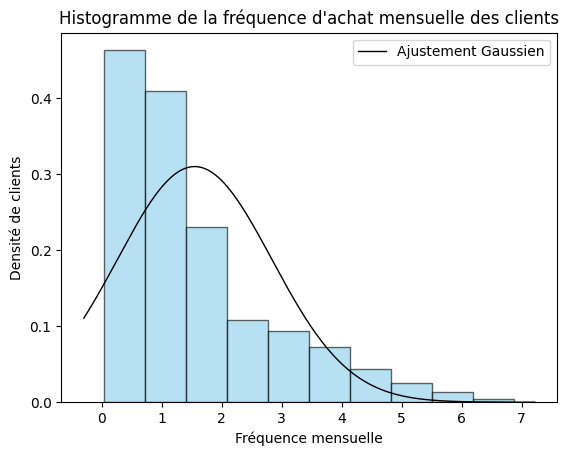

In [140]:
frequence  = df_session_frequency['freq_achat_par_mois']

# Calculer la moyenne et l'écart type
mean_frequence = frequence.mean()
std_frequence = frequence.std()

# Afficher les valeurs calculées
print(f"Moyenne des dépenses : {mean_frequence}")
print(f"Écart type des dépenses : {std_frequence}")

# Effectuer le test de Shapiro-Wilk 
stat, p_value = shapiro(depenses)

# Afficher les résultats
print("taille de mon échantillon :", len(frequence))
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# H0 : la variable âge suit une distribution normale
# H1 : la variable âge ne suit pas une distribution normale

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

plt.hist(frequence, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(frequence)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, frequence.count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=1, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme de la fréquence d\'achat mensuelle des clients')
plt.xlabel('Fréquence mensuelle')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

On a  déjà vu que l'âge ne suivait pas une distribution normale. On fait donc un test de spearman.

Coefficient de corrélation de Spearman: 0.212296770973657
Valeur p: 3.5049079111603754e-88


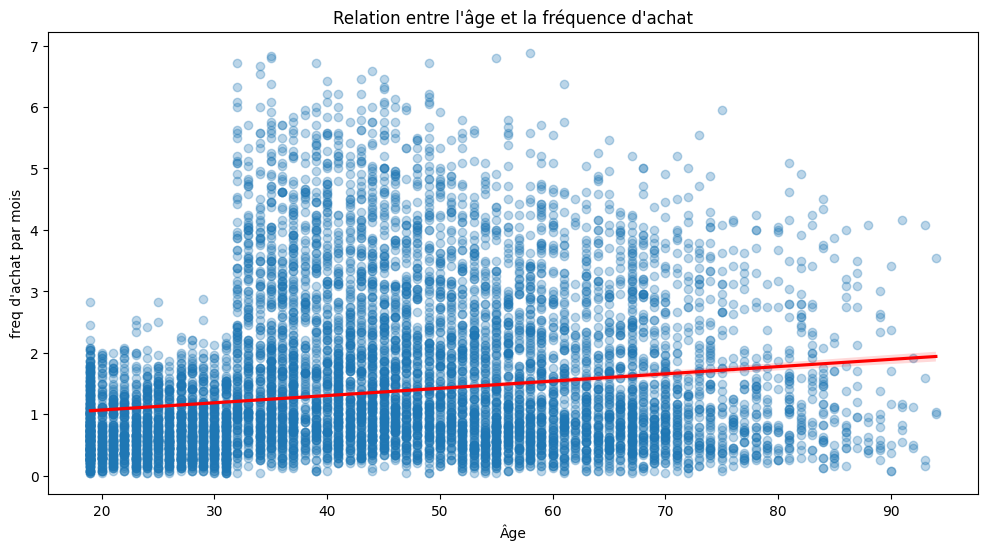

In [113]:
age  = df_session_frequency['âge']
frequence  = df_session_frequency['freq_achat_par_mois']

plt.figure(figsize=(12, 6))
sns.regplot(x='âge', y='freq_achat_par_mois', data=df_session_frequency, robust=True,
            scatter_kws={'alpha':0.3},
            line_kws={"color": "red"})

plt.title('Relation entre l\'âge et la fréquence d\'achat')
plt.xlabel('Âge')
plt.ylabel('freq d\'achat par mois')

# Calculer le coefficient de corrélation de Spearman et p-alue
spearman_corr, spearman_p_value = spearmanr(age, frequence)

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

On observe une corrélation positive et statistiquement significative (p<0.05), mais faible (r=0.21). Cela montre que l'âge n'est pas le seul facteur explicatif de la fréquence d'achat mais qu'il l'influence positivement. Nous allons utiliser les catégories d'âge des clients plutot que la variable discrète de l'âge pour voir si les résultats sont plus probants.
<br>
Afin d'affiner cette analyse, nous avons segmenté l'âge en catégories pour observer des comportements de groupes plus homogènes.
<br>
Une ANOVA a été effectuée pour comparer la fréquence d'achat des clients en fonction de leur catégorie d'âge. Ce test est idéal pour comparer les moyennes de plusieurs groupes et évaluer les différences entre eux. <br>
Objectif de l'étude<br>
Cette analyse visait à identifier quel tranche d'âge achète le plus souvent, permettant à Lapage de mieux connaitre sa clientelle et d'améliorer sa stratégie de rétention.

Text(0, 0.5, "freq d'achat par mois")

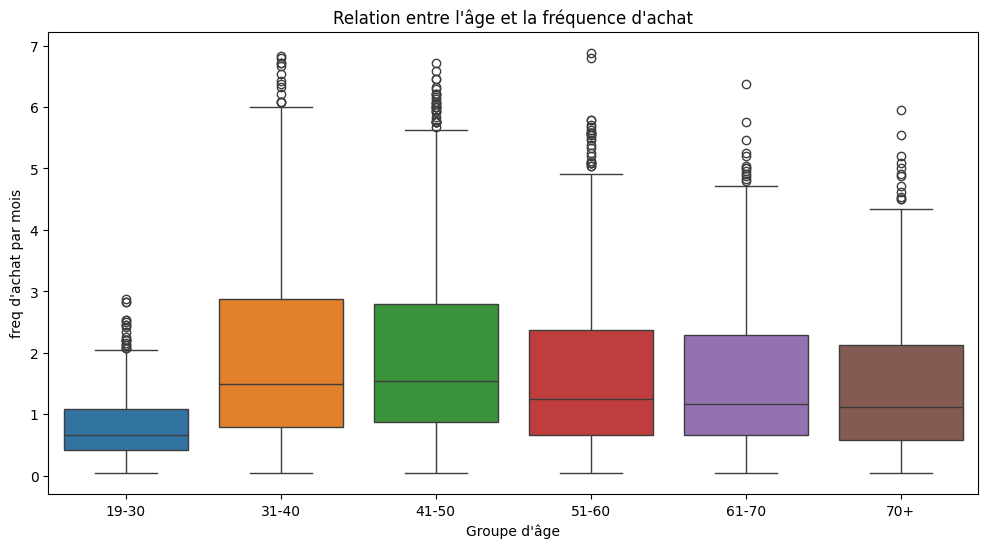

In [114]:
# On visualise nos variables d'intérêts
df_session_frequency = df_session_frequency.sort_values(by='age_group', ascending=True).reset_index()
plt.figure(figsize=(12, 6))
sns.boxplot(x='age_group', y='freq_achat_par_mois', data=df_session_frequency, hue='age_group')
plt.title('Relation entre l\'âge et la fréquence d\'achat')
plt.xlabel("Groupe d'âge")
plt.ylabel('freq d\'achat par mois')

Le groupe 19-30 ans est à part : Ils ont la fréquence la plus basse et la plus stable (la boîte est très "plate"). Ils achètent peu souvent.

Le pic de fréquence (31-50 ans) : Ce sont tes clients les plus réguliers. Les boîtes sont plus hautes.

La stabilisation (50+) : La fréquence redescend légèrement mais reste plus élevée que chez les très jeunes.

In [158]:
# Sélectionner les colonnes pertinentes pour chaque catégorie
age_19_30 = df_session_frequency[df_session_frequency['age_group'] == '19-30']['freq_achat_par_mois'].dropna()
age_31_40 = df_session_frequency[df_session_frequency['age_group'] == '31-40']['freq_achat_par_mois'].dropna()
age_41_50 = df_session_frequency[df_session_frequency['age_group'] == '41-50']['freq_achat_par_mois'].dropna()
age_51_60 = df_session_frequency[df_session_frequency['age_group'] == '51-60']['freq_achat_par_mois'].dropna()
age_61_70 = df_session_frequency[df_session_frequency['age_group'] == '61-70']['freq_achat_par_mois'].dropna()
age_70_plus = df_session_frequency[df_session_frequency['age_group'] == '70+']['freq_achat_par_mois'].dropna()

# Calcul du test de Levene pour valider la possibilité d'Anova
stat_levene, p_levene = levene(age_19_30, age_31_40, age_41_50, 
                               age_51_60, age_61_70, age_70_plus)

print(f"Statistique de Levene : {stat_levene}")
print(f"Valeur p (Levene) : {p_levene}")

# 2. Interprétation automatique
if p_levene < 0.05:
    print("Résultat : Les variances sont significativement différentes (Hétéroscédasticité).")
    print("Conseil : L'ANOVA classique est risquée. Utilise l'ANOVA de Welch.")
else:
    print("Résultat : Les variances sont homogènes. L'ANOVA classique est valide.")

Statistique de Levene : 209.449907859147
Valeur p (Levene) : 2.01113938967869e-211
Résultat : Les variances sont significativement différentes (Hétéroscédasticité).
Conseil : L'ANOVA classique est risquée. Utilise l'ANOVA de Welch.


In [159]:
# Calculer le test ANOVA et la valeur p
f_stat, p_value = f_oneway(age_19_30, age_31_40, age_41_50, age_51_60, age_61_70, age_70_plus)

print(f"Statistique de test F: {f_stat}")
print(f"Valeur p: {p_value}")

Statistique de test F: 253.2500321886597
Valeur p: 3.1553602500941314e-253


In [ ]:
# Effectuer l'ANOVA de Welch
welch_anova = pg.welch_anova(data=df_session_frequency, dv='freq_achat_par_mois', between='age_group')

# Afficher les résultats
print(welch_anova)

      Source  ddof1        ddof2           F  p_unc       np2
0  age_group      5  2931.135712  522.125726    0.0  0.128472


Le boxplot permet de clairement voir une différence de fréquence en fonction de la catégorie d'âge .
La statistique de test F compare la variation entre les groupes à la variation au sein de chaque groupe. Une valeur F aussi forte (253) suggère une différence entre les moyennes des groupes. La valeur p indique la probabilité que la différence observée entre les groupes soit due au hasard. Une valeur p inférieure au seuil de 0,05 indique que la différence est statistiquement significative. Ainsi, nous observons des différences significatives entre les âges et la fréquence d'achat.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.4 - Âge et taille du panier</h3>
</div>

Le test de Spearman, un test de corrélation non paramétrique, a été utilisé pour étudier la relation entre l'âge des clients et la taille de leurs paniers. Contrairement à Pearson, Spearman ne nécessite pas que les données soient normalement distribuées et est efficace pour analyser les relations monotones, même si elles ne sont pas strictement linéaires. <br>
Objectif de l'étude : <br>
Ce test visait à identifier si un âge plus avancé est associé à des paniers plus grands, une information clé pour augmenter le panier moyen.

In [133]:
#On a déjà notre df_session qui regroupe nos paniers avec l'âge du client
# On peut donc directement faire notre Spearman car on sait que nos variables ne suivent pas une loi normale.

age  = df_session['âge']
nb_articles  = df_session['nb_articles']

# Calculer le coefficient de corrélation de Spearman et p-alue
spearman_corr, spearman_p_value = spearmanr(age, nb_articles)

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

Coefficient de corrélation de Spearman: -0.23423035447085983
Valeur p: 0.0


Moyenne des dépenses : 44.739646347138205
Écart type des dépenses : 16.910541505897303
taille de mon échantillon : 8596
Statistique du test de Shapiro-Wilk : 0.9697306402580154
Valeur p : 4.615340399612398e-39
Les données ne suivent pas une distribution normale (on rejette H0)


c:\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


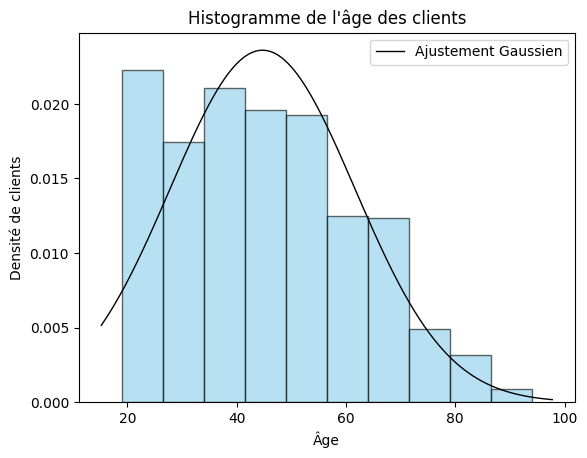

In [139]:
# Calculer la moyenne et l'écart type
mean_age = age.mean()
std_age = age.std()

# Afficher les valeurs calculées
print(f"Moyenne des dépenses : {mean_age}")
print(f"Écart type des dépenses : {std_age}")

# Effectuer le test de Shapiro-Wilk 
stat, p_value = shapiro(age)

# Afficher les résultats
print("taille de mon échantillon :", len(age))
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# H0 : la variable âge suit une distribution normale
# H1 : la variable âge ne suit pas une distribution normale

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

plt.hist(age, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(age)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, age.count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=1, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme de l\'âge des clients')
plt.xlabel('Âge')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

Moyenne des dépenses : 1.9812145835225867
Écart type des dépenses : 1.2701141940142677
taille de mon échantillon : 319237
Statistique du test de Shapiro-Wilk : 0.9036921578731572
Valeur p : 1.1350044673532336e-58
Les données ne suivent pas une distribution normale (on rejette H0)


c:\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


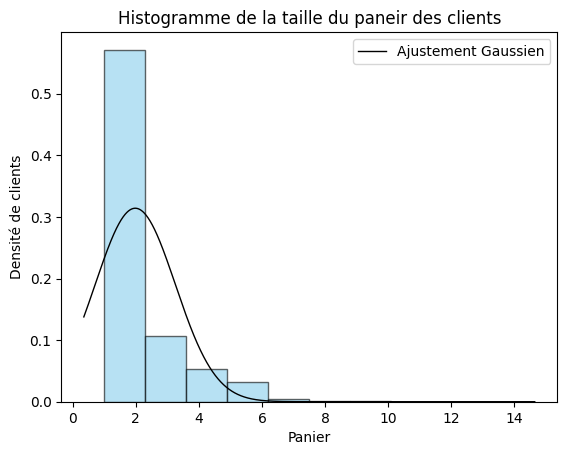

In [142]:
# Calculer la moyenne et l'écart type
mean_nb_articles = nb_articles.mean()
std_nb_articles = nb_articles.std()

# Afficher les valeurs calculées
print(f"Moyenne des dépenses : {mean_nb_articles}")
print(f"Écart type des dépenses : {std_nb_articles}")

# Effectuer le test de Shapiro-Wilk 
stat, p_value = shapiro(depenses)

# Afficher les résultats
print("taille de mon échantillon :", len(nb_articles))
print(f"Statistique du test de Shapiro-Wilk : {stat}")
print(f"Valeur p : {p_value}")

# H0 : la variable âge suit une distribution normale
# H1 : la variable âge ne suit pas une distribution normale

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

plt.hist(nb_articles, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(nb_articles)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, nb_articles.count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=1, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme de la taille du paneir des clients')
plt.xlabel('Panier')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

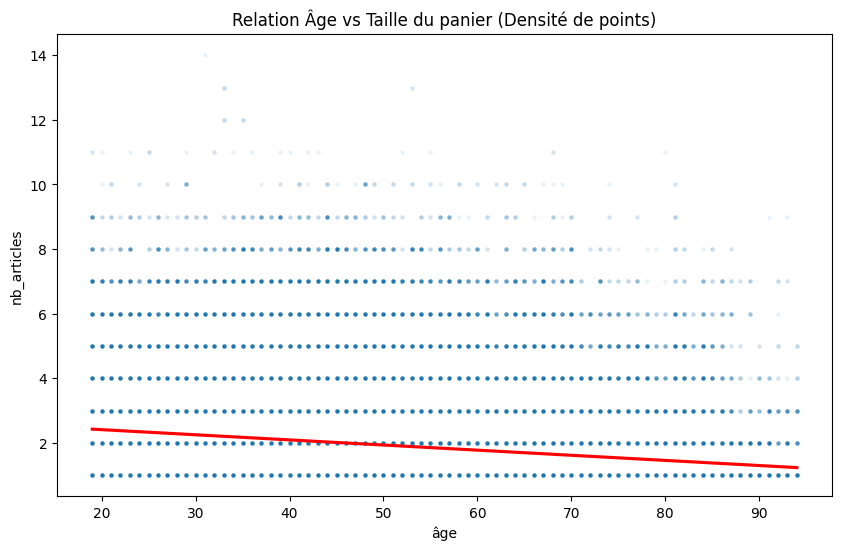

In [117]:
plt.figure(figsize=(10, 6))

# On utilise s=1 pour des points minuscules et alpha pour la transparence
sns.scatterplot(data=df_session, x='âge', y='nb_articles', alpha=0.1, s=10)

# On ajoute la ligne de régression manuellement (très rapide)
sns.regplot(data=df_session, x='âge', y='nb_articles', scatter=False, color='red', label='Tendance')

plt.title("Relation Âge vs Taille du panier (Densité de points)")
plt.show()

On observe une corrélation négative et statistiquement significative (p<0.05), mais faible (r=-0.23). Cela montre que l'âge n'est pas le seul facteur explicatif de la taille du panier mais qu'il l'influence négativement. Nous allons utiliser les catégories d'âge des clients plutot que la variable discrète de l'âge pour voir si les résultats sont plus probants.
<br>
Afin d'affiner cette analyse, nous avons segmenté l'âge en catégories pour observer des comportements de groupes plus homogènes.
<br>
Une ANOVA a été effectuée pour comparer la taille des paniers des clients en fonction de leur catégorie d'âge. Ce test est idéal pour comparer les moyennes de plusieurs groupes et évaluer les différences entre eux. <br>
Objectif de l'étude<br>
Cette analyse visait à identifier quel tranche d'âge achète le plus souvent, permettant à Lapage de mieux connaitre sa clientelle et d'améliorer sa stratégie de rétention.

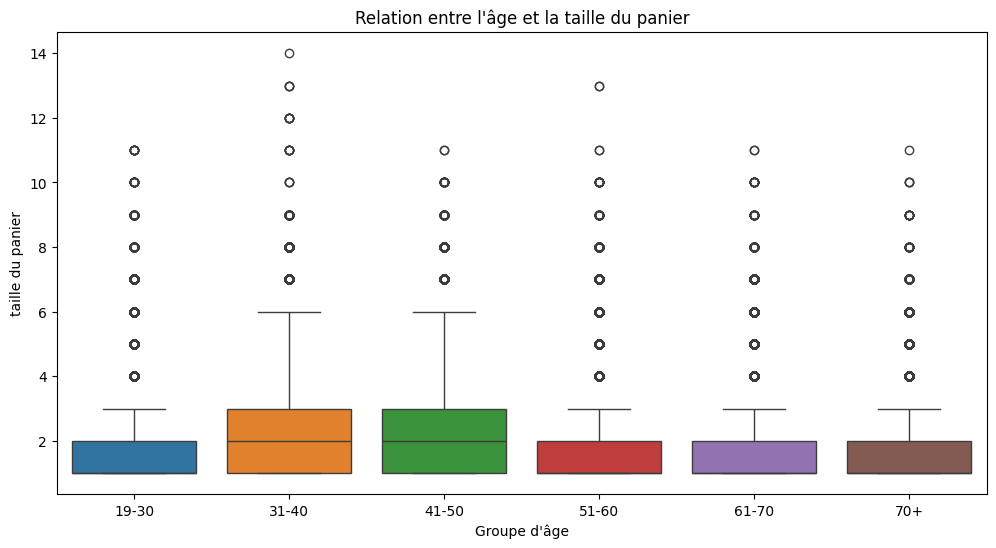

In [118]:
df_session = df_session.sort_values(by='age_group', ascending=True)
plt.figure(figsize=(12, 6))
sns.boxplot(x='age_group', y='nb_articles', data=df_session, hue='age_group')
plt.title('Relation entre l\'âge et la taille du panier')
plt.xlabel("Groupe d'âge")
plt.ylabel('taille du panier')
plt.show()

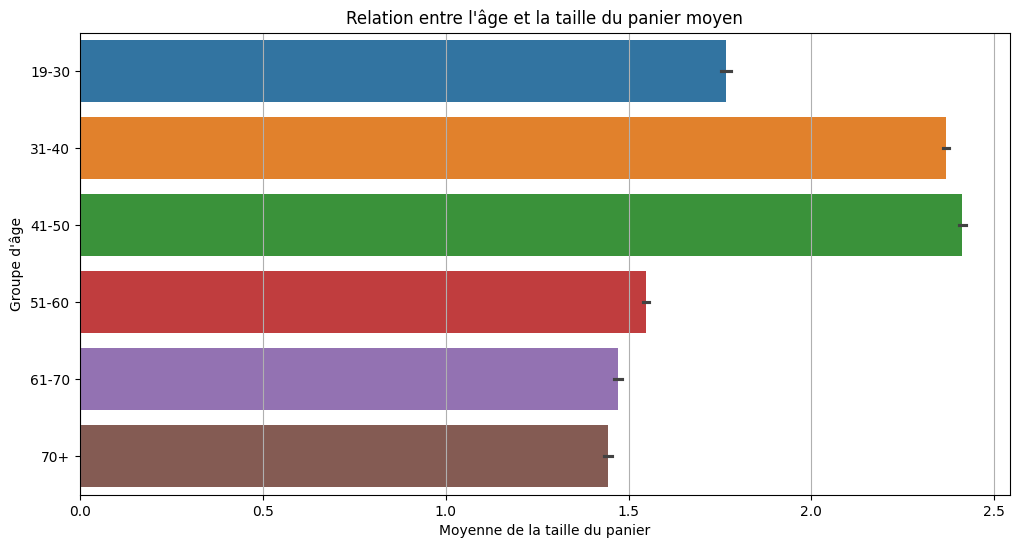

In [119]:
plt.figure(figsize=(12, 6))
sns.barplot(x='nb_articles', y='age_group', data=df_session, hue='age_group')
plt.title('Relation entre l\'âge et la taille du panier moyen')
plt.grid(axis='x')
plt.ylabel("Groupe d'âge")
plt.xlabel('Moyenne de la taille du panier')
plt.show()

Le groupe 19-30 ans : Panier moyen ~1.7 articles. 

Le pic (31-50 ans) : Ce sont les clients qui ont les paniers les plus grands (>2.3).

La stabilisation (50+) : Panier moyen <= 1.5 articles. Clairement un axe d'amélioration

In [149]:
# Sélectionner les colonnes pertinentes pour chaque catégorie
age_19_30 = df_session[df_session['age_group'] == '19-30']['nb_articles'].dropna()
age_31_40 = df_session[df_session['age_group'] == '31-40']['nb_articles'].dropna()
age_41_50 = df_session[df_session['age_group'] == '41-50']['nb_articles'].dropna()
age_51_60 = df_session[df_session['age_group'] == '51-60']['nb_articles'].dropna()
age_61_70 = df_session[df_session['age_group'] == '61-70']['nb_articles'].dropna()
age_70_plus = df_session[df_session['age_group'] == '70+']['nb_articles'].dropna()

# Calcul du test de Levene pour valider la possibilité d'Anova
stat_levene, p_levene = levene(age_ca_19_30, age_ca_31_40, age_ca_41_50, 
                               age_ca_51_60, age_ca_61_70, age_ca_70_plus)

print(f"Statistique de Levene : {stat_levene}")
print(f"Valeur p (Levene) : {p_levene}")

# 2. Interprétation automatique
if p_levene < 0.05:
    print("Résultat : Les variances sont significativement différentes (Hétéroscédasticité).")
    print("Conseil : L'ANOVA classique est risquée. Utilise l'ANOVA de Welch.")
else:
    print("Résultat : Les variances sont homogènes. L'ANOVA classique est valide.")

# Calculer le test ANOVA et la valeur p
f_stat, p_value = f_oneway(age_19_30, age_31_40, age_41_50, age_51_60, age_61_70, age_70_plus)

print(f"Statistique de test F: {f_stat}")
print(f"Valeur p: {p_value}")

Statistique de Levene : 79.5405457395784
Valeur p (Levene) : 7.544112240711467e-82
Résultat : Les variances sont significativement différentes (Hétéroscédasticité).
Conseil : L'ANOVA classique est risquée. Utilise l'ANOVA de Welch.
Statistique de test F: 7865.323065054801
Valeur p: 0.0


In [150]:
# Calculer le test ANOVA et la valeur p
f_stat, p_value = f_oneway(age_19_30, age_31_40, age_41_50, age_51_60, age_61_70, age_70_plus)

print(f"Statistique de test F: {f_stat}")
print(f"Valeur p: {p_value}")

Statistique de test F: 7865.323065054801
Valeur p: 0.0


In [162]:
# Effectuer l'ANOVA de Welch
welch_anova = pg.welch_anova(data=df_session, dv='nb_articles', between='age_group')

# Afficher les résultats
print(welch_anova)

      Source  ddof1          ddof2            F  p_unc      np2
0  age_group      5  117864.120456  8409.331387    0.0  0.10968


Le boxplot permet de clairement voir une différence de taille du panier en fonction de la catégorie d'âge .
La statistique de test F compare la variation entre les groupes à la variation au sein de chaque groupe. Une valeur F aussi forte (7865) suggère une différence entre les moyennes des groupes. La valeur p indique la probabilité que la différence observée entre les groupes soit due au hasard. Une valeur p inférieure au seuil de 0,05 indique que la différence est statistiquement significative. Ainsi, nous observons des différences significatives entre les âges et la taille du panier.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.5 - Âge et catégorie de livre</h3>
</div>

Text(0.5, 0, 'Catégorie')

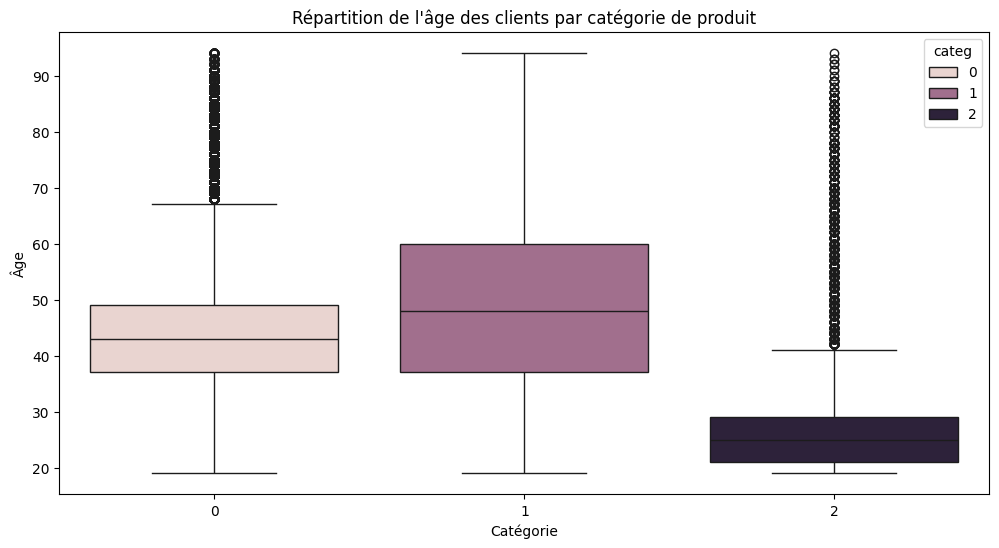

In [121]:
# On visualise nos variables d'intérêts
plt.figure(figsize=(12, 6))
sns.boxplot(x="categ", y="âge", data=df_b2c, hue='categ')
plt.title('Répartition de l\'âge des clients par catégorie de produit')
plt.ylabel("Âge")
plt.xlabel('Catégorie')


Visuellement, chaque catégorie a une boîte relativement plate mise à part la catégorie 1. les différences entre elles sont assez claires. <br>
Chi² ou Anova ? On va voir lequel est le plus pertinent en regardant la variance de la variable âge pour chaque catégorie de produit.

In [122]:
# Sélectionner les colonnes pertinentes pour chaque catégorie
categ_0 = df_final_date_formate[df_final_date_formate['categ'] == 0]['âge'].dropna()
categ_1 = df_final_date_formate[df_final_date_formate['categ'] == 1]['âge'].dropna()
categ_2 = df_final_date_formate[df_final_date_formate['categ'] == 2]['âge'].dropna()

In [123]:
print(df_final_date_formate.groupby('categ')['âge'].mean())

categ
0    44.897446
1    48.651238
2    26.948031
Name: âge, dtype: float64


In [124]:
print(df_final_date_formate.groupby('categ')['âge'].std())

categ
0    11.209687
1    15.495910
2     9.798143
Name: âge, dtype: float64


On voit que nos variance sont trop éloignées, un CHi² me semble plus approprié en regroupant l'âge des clients en catégories.

Le test du Chi-carré a été utilisé pour vérifier la dépendance entre l'âge des clients et les catégories de produits achetés. Ce test est adapté pour
examiner les associations entre variables catégoriques dans de grands tableaux de contingence. <br>
Objectif de l'étude<br>
L'analyse visait à déterminer si les choix des produits varient en fonction de l'âge, une information utile pour orienter des offres et le marketing.

Text(0.5, 0, 'Catégorie')

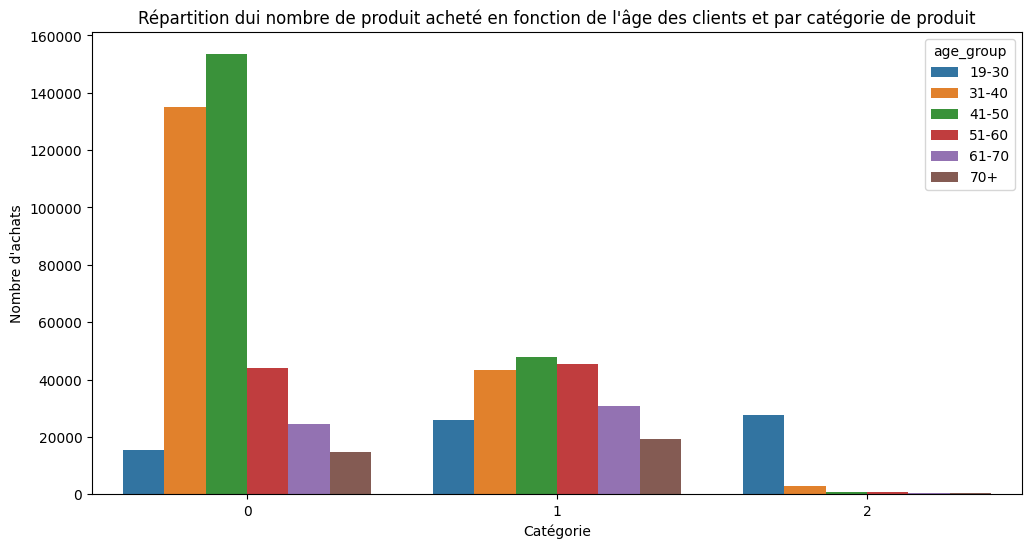

In [125]:
# Créer le tableau de contingence
contingency_table = pd.crosstab(df_b2c['age_group'], df_b2c['categ'])
plt.figure(figsize=(12, 6))
order_age = ['19-30', '31-40', '41-50', '51-60', '61-70', '70+']
sns.countplot(data=df_b2c, x='categ', hue='age_group', hue_order=order_age)
plt.title('Répartition dui nombre de produit acheté en fonction de l\'âge des clients et par catégorie de produit')
plt.ylabel("Nombre d'achats")
plt.xlabel('Catégorie')

Catégorie 0 : On observe une nette prédominance des 31-50 ans. C'est le cœur de l'activité de Lapage en volume. La chute drastique des ventes après 60 ans est un axe d'amélioration sur l'accessibilité pour les seniors.

Catégorie 1 : Cette catégorie présente une distribution "en cloche" équilibrée. Elle semble plaire à toutes les générations avec un pic chez les 41-60 ans.

Catégorie 2 : Cette catégorie est exclusivement portée par les 19-30 ans. C'est un segment de niche très marqué où les autres tranches d'âge sont quasiment absentes.

In [126]:
# Calculer le test du Chi-2
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Statistique Chi-2: {chi2_stat}")
print(f"Valeur p: {p_value}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)
print("Fréquences réelles:")
display(contingency_table)

Statistique Chi-2: 248227.6678456431
Valeur p: 0.0
Degrés de liberté: 10
Fréquences attendues:
[[ 42152.40086201  23112.36032298   3575.23881501]
 [111059.69718108  60894.55608979   9419.74672913]
 [123802.16467002  67881.31114965  10500.52418033]
 [ 55068.15611161  30194.12987982   4670.71400857]
 [ 34257.09207766  18783.3252561    2905.58266625]
 [ 20941.48909763  11482.31730166   1776.19360072]]
Fréquences réelles:


categ,0,1,2
age_group,,,
19-30,15446,25863,27531
31-40,135156,43228,2990
41-50,153457,47958,769
51-60,43899,45316,718
61-70,24549,30858,539
70+,14774,19125,301


Le test du Chi-deux a confirmé une dépendance très forte (25000 vs degré de liberté: 10) entre l'âge et la catégorie (p-value < 0,05), ce qui valide visuellement les contrastes observés ici."

Text(0.5, 0, 'Catégorie')

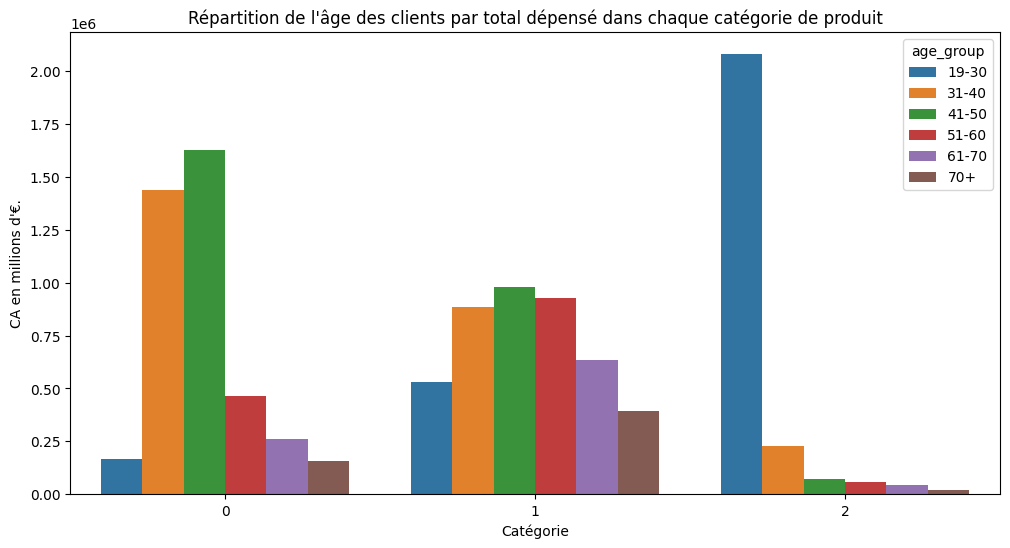

In [127]:
# je suis curieux de voir la même chose mais en CA au lieu du nombre d'achats
df_ca_categ_age_group = df_b2c.groupby(['age_group', 'categ'])['CA'].sum().reset_index()

plt.figure(figsize=(12, 6))
order_age = ['19-30', '31-40', '41-50', '51-60', '61-70', '70+']
sns.barplot(data=df_ca_categ_age_group, x='categ', y='CA', hue='age_group', hue_order=order_age, estimator='sum')
plt.title('Répartition de l\'âge des clients par total dépensé dans chaque catégorie de produit')
plt.ylabel("CA en millions d'€.")
plt.xlabel('Catégorie')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape  - risques liés aux tests </h2>
</div>

Les données clients utilisées étaient limitées aux informations recueillies à
partir de 2021, ce qui peut ne pas représenter les tendances à long terme ou
les changements de comportements qui se développent sur plusieurs années.
En outre, bien que des efforts aient été déployés pour nettoyer les données,
incluant le traitement des valeurs manquantes et la suppression des doublons,
il reste un risque d'erreurs résiduelles qui pourraient affecter les analyses.
<br>
<br>
L'omniprésence de clients professionnels (B2B) aux volumes d'achats atypiques peut biaiser les résultats des tests de corrélation s'ils ne sont pas traités séparément du segment B2C. Je peux en avoir conservé dans mon dataset.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape  - Recommandations </h2>
</div>

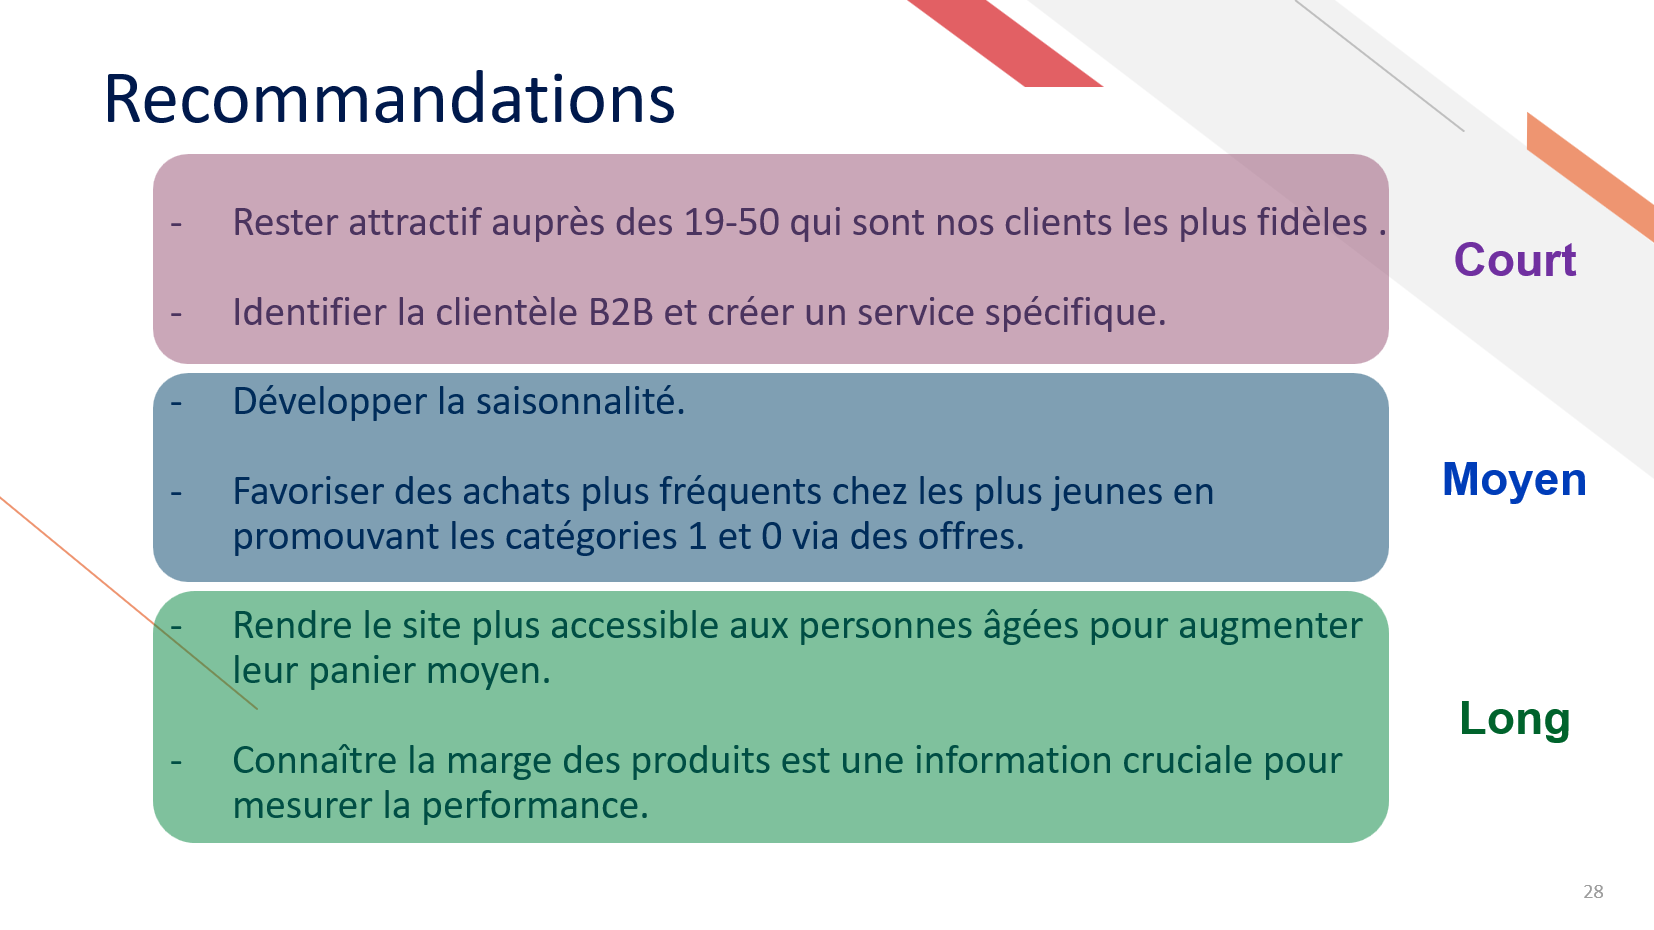